# 🏠 House Price Prediction — A Complete Regression Study
### From Raw Property Data to Accurate Price Forecasting

---

## 🎯 Problem Statement & Goal

> **Goal:** Build regression models to predict house prices based on key property features — area, bedrooms, bathrooms, stories, and location attributes — and identify which factors drive real estate value most.

The **House Price Prediction Dataset** (Kaggle) contains **545 property records** across 13 features, covering structural attributes (size, rooms) and amenity indicators (air conditioning, basement, preferred area).

### 📋 Feature Reference Table

| Feature | Type | Description |
|---------|------|-------------|
| `area` | Numeric | Property size in square feet |
| `bedrooms` | Numeric | Number of bedrooms |
| `bathrooms` | Numeric | Number of bathrooms |
| `stories` | Numeric | Number of floors |
| `mainroad` | Binary | Connected to main road (yes/no) |
| `guestroom` | Binary | Has a guest room (yes/no) |
| `basement` | Binary | Has a basement (yes/no) |
| `hotwaterheating` | Binary | Has hot water heating (yes/no) |
| `airconditioning` | Binary | Has air conditioning (yes/no) |
| `parking` | Numeric | Number of parking spots |
| `prefarea` | Binary | Located in preferred area (yes/no) |
| `furnishingstatus` | Categorical | furnished / semi-furnished / unfurnished |
| **`price`** | **Numeric** | **Target — Sale price** |

### 🗺️ Project Roadmap:
1. Load & inspect the dataset
2. Clean & preprocess (encode categoricals, handle missing values)
3. Deep EDA — 10 visualizations
4. Train **2 regression models** (Linear Regression + Gradient Boosting)
5. Evaluate with MAE, RMSE, MAPE, and R²
6. Feature importance analysis — 3 methods
7. Summary dashboard & final insights

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — IMPORTS & GLOBAL STYLE CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# ── Global visual theme ───────────────────────────────────────────────────────
BG     = '#0D1117'
PANEL  = '#161B22'
GRID   = '#21262D'
TEXT   = '#E6EDF3'
BLUE   = '#58A6FF'
GREEN  = '#3FB950'
ORANGE = '#F78166'
PURPLE = '#BC8CFF'
GOLD   = '#E3B341'
RED    = '#FF6B6B'
TEAL   = '#4ECDC4'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   TEXT,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.grid':         True,
    'grid.color':        GRID,
    'grid.linewidth':    0.5,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'legend.facecolor':  PANEL,
    'legend.edgecolor':  GRID,
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        130,
})

print('✅ All libraries loaded.')
print('✅ Dark theme configured.')

## Step 2 — Load the Dataset

The dataset (`Housing.csv`) is included in this repository. No download needed.

Source: [Housing Price Prediction | Kaggle](https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction?select=Housing.csv)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv('Housing.csv')

print('✅ Dataset loaded successfully!')
print(f'   Shape   : {df.shape}')
print(f'   Columns : {df.columns.tolist()}')
print(f'\n📋 First 5 rows:')
df.head()

✅ Dataset loaded successfully!
   Shape   : (545, 13)
   Columns : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

📋 First 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Step 3 — Initial Inspection

Before any modeling, we inspect the raw data to understand its structure, types, and statistical profile.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAPE, INFO, DESCRIBE
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows         : {df.shape[0]}')
print(f'  Columns      : {df.shape[1]}')
print(f'  Missing vals : {df.isnull().sum().sum()}')
print(f'  Price range  : {df["price"].min():,.0f}  →  {df["price"].max():,.0f}')
print('=' * 55)
print()
df.info()

  DATASET OVERVIEW
  Rows         : 545
  Columns      : 13
  Missing vals : 0
  Price range  : 1,750,000  →  13,300,000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Statistical summary — all features at a glance
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


## Step 4 — Data Cleaning & Preprocessing

Two types of columns require encoding before modeling:
- **Binary yes/no columns** → mapped to 1 / 0
- **`furnishingstatus`** → ordinal encoding: `furnished=2`, `semi-furnished=1`, `unfurnished=0`

This preserves the natural ordering (fully furnished > semi > unfurnished) in a single interpretable numeric column.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# MISSING VALUE CHECK
# ─────────────────────────────────────────────────────────────────────────────

missing = df.isnull().sum()
print('Missing Value Report:')
print('-' * 35)
if missing.sum() == 0:
    print('  ✅ No missing values found — dataset is clean.')
else:
    for col in df.columns:
        if missing[col] > 0:
            print(f'  {col:<20}: {missing[col]} missing')

print()

# ─────────────────────────────────────────────────────────────────────────────
# ENCODE BINARY COLUMNS (yes → 1, no → 0)
# ─────────────────────────────────────────────────────────────────────────────

BINARY_COLS = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in BINARY_COLS:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f'  ✅ {col}: encoded  (yes=1, no=0)')

# ─────────────────────────────────────────────────────────────────────────────
# ENCODE FURNISHING STATUS — ordinal (preserves natural ranking)
# ─────────────────────────────────────────────────────────────────────────────

FURNISH_MAP = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df['furnishingstatus'] = df['furnishingstatus'].map(FURNISH_MAP)
print(f'  ✅ furnishingstatus: encoded  (furnished=2, semi-furnished=1, unfurnished=0)')

print(f'\n✅ Preprocessing complete. Shape: {df.shape}')
print('   All columns are now numeric — ready for modeling.')
df.head()

Missing Value Report:
-----------------------------------
  ✅ No missing values found — dataset is clean.

  ✅ mainroad: encoded  (yes=1, no=0)
  ✅ guestroom: encoded  (yes=1, no=0)
  ✅ basement: encoded  (yes=1, no=0)
  ✅ hotwaterheating: encoded  (yes=1, no=0)
  ✅ airconditioning: encoded  (yes=1, no=0)
  ✅ prefarea: encoded  (yes=1, no=0)
  ✅ furnishingstatus: encoded  (furnished=2, semi-furnished=1, unfurnished=0)

✅ Preprocessing complete. Shape: (545, 13)
   All columns are now numeric — ready for modeling.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## Step 5 — Exploratory Data Analysis (EDA)

Ten visualizations revealing pricing patterns, feature distributions, and correlations.

| # | Plot | What It Reveals |
|---|------|----------------|
| 5.1 | Price Distribution | Shape, skew, and spread of the target variable |
| 5.2 | Price vs Area | The core size–price relationship |
| 5.3 | Price by Bedrooms | How bedroom count affects value |
| 5.4 | Price by Bathrooms | Bathroom count vs price |
| 5.5 | Price by Stories | Multi-floor premium |
| 5.6 | Correlation Heatmap | Inter-feature relationships |
| 5.7 | Amenity Features vs Price | AC, basement, mainroad, prefarea effect |
| 5.8 | Price by Furnishing Status | Furnished vs unfurnished premium |
| 5.9 | Price by Parking Spots | Parking availability vs price |
| 5.10 | Scatter Matrix | Pairwise relationships between key features |

---

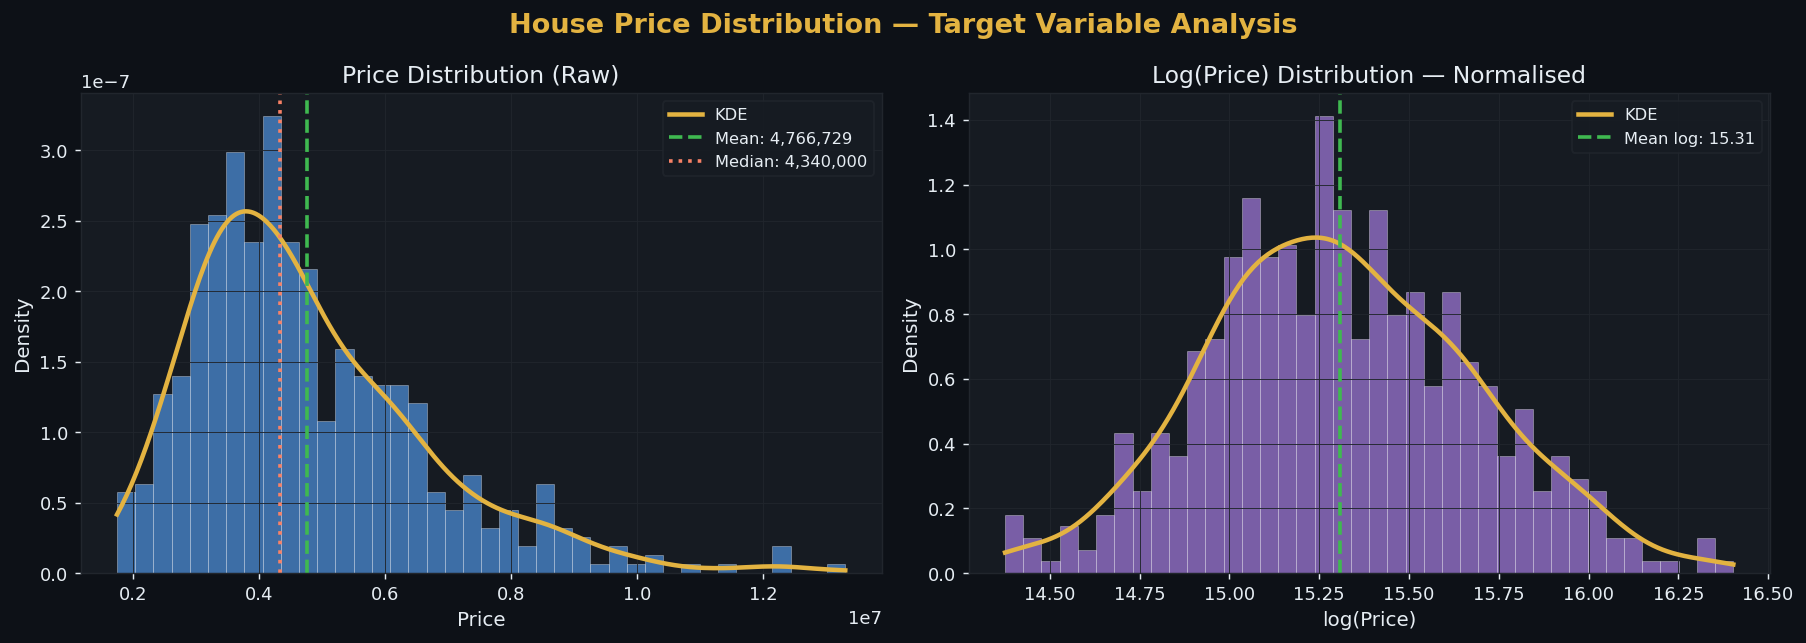

📌 Price skewness: 1.209 — right-skewed (common in real estate data).
   Mean: 4,766,729  |  Median: 4,340,000  |  Std: 1,870,440


In [6]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.1 — PRICE DISTRIBUTION (Raw + Log-Transformed)
# Log transform reduces right-skew, which helps linear models perform better.
# ═════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price Distribution — Target Variable Analysis',
             fontsize=15, color=GOLD, fontweight='bold')

price = df['price']

# ── Raw price histogram + KDE ──
ax1.hist(price, bins=40, color=BLUE, alpha=0.6, density=True,
         edgecolor='white', linewidth=0.3)
kde_x = np.linspace(price.min(), price.max(), 300)
ax1.plot(kde_x, gaussian_kde(price)(kde_x), color=GOLD, lw=2.5, label='KDE')
ax1.axvline(price.mean(),   color=GREEN,  lw=2, linestyle='--',
            label=f'Mean: {price.mean():,.0f}')
ax1.axvline(price.median(), color=ORANGE, lw=2, linestyle=':',
            label=f'Median: {price.median():,.0f}')
ax1.set_title('Price Distribution (Raw)')
ax1.set_xlabel('Price')
ax1.set_ylabel('Density')
ax1.legend()

# ── Log-transformed price ──
log_price = np.log(price)
ax2.hist(log_price, bins=40, color=PURPLE, alpha=0.6, density=True,
         edgecolor='white', linewidth=0.3)
kde_x2 = np.linspace(log_price.min(), log_price.max(), 300)
ax2.plot(kde_x2, gaussian_kde(log_price)(kde_x2), color=GOLD, lw=2.5, label='KDE')
ax2.axvline(log_price.mean(), color=GREEN, lw=2, linestyle='--',
            label=f'Mean log: {log_price.mean():.2f}')
ax2.set_title('Log(Price) Distribution — Normalised')
ax2.set_xlabel('log(Price)')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

skew = stats.skew(price)
print(f'📌 Price skewness: {skew:.3f} — right-skewed (common in real estate data).')
print(f'   Mean: {price.mean():,.0f}  |  Median: {price.median():,.0f}  |  Std: {price.std():,.0f}')

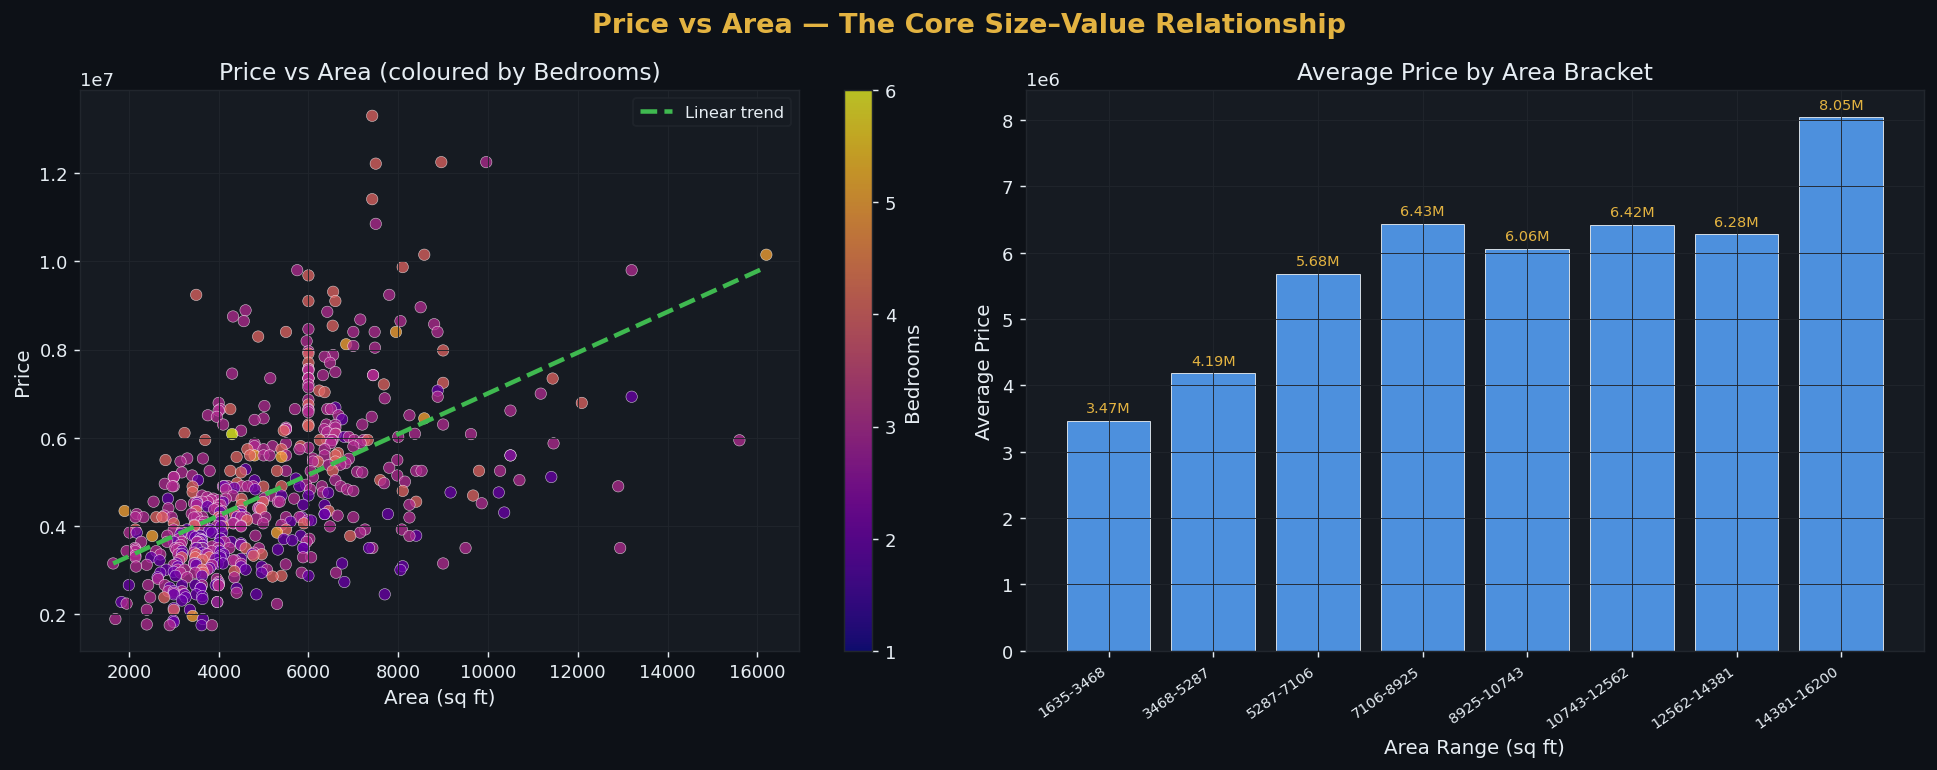

📌 Pearson correlation (area ↔ price): r = 0.536
   Area is the strongest single numeric predictor of house price.


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.2 — PRICE vs AREA (Core Size–Value Relationship)
# Scatter coloured by bedroom count + average price by area bracket.
# ═════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Price vs Area — The Core Size–Value Relationship',
             fontsize=15, color=GOLD, fontweight='bold')

# ── Scatter coloured by bedrooms ──
scatter = ax1.scatter(df['area'], df['price'],
                      c=df['bedrooms'], cmap='plasma',
                      s=40, alpha=0.75, edgecolors='white', linewidths=0.3)
plt.colorbar(scatter, ax=ax1, label='Bedrooms')

# Linear trend line
m, b = np.polyfit(df['area'], df['price'], 1)
xs = np.linspace(df['area'].min(), df['area'].max(), 200)
ax1.plot(xs, m*xs + b, color=GREEN, lw=2.5, linestyle='--', label='Linear trend')
ax1.set_xlabel('Area (sq ft)')
ax1.set_ylabel('Price')
ax1.set_title('Price vs Area (coloured by Bedrooms)')
ax1.legend()

# ── Binned average price by area bracket ──
df['area_bin'] = pd.cut(df['area'], bins=8)
avg_price = df.groupby('area_bin')['price'].mean()
bin_labels = [f'{int(b.left)}-{int(b.right)}' for b in avg_price.index]

bars = ax2.bar(range(len(avg_price)), avg_price.values,
               color=BLUE, edgecolor='white', linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, avg_price.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + avg_price.values.max()*0.01,
             f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=8, color=GOLD)
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=35, ha='right', fontsize=8)
ax2.set_title('Average Price by Area Bracket')
ax2.set_xlabel('Area Range (sq ft)')
ax2.set_ylabel('Average Price')

df.drop(columns='area_bin', inplace=True)
plt.tight_layout()
plt.show()

corr_area = df['area'].corr(df['price'])
print(f'📌 Pearson correlation (area ↔ price): r = {corr_area:.3f}')
print('   Area is the strongest single numeric predictor of house price.')

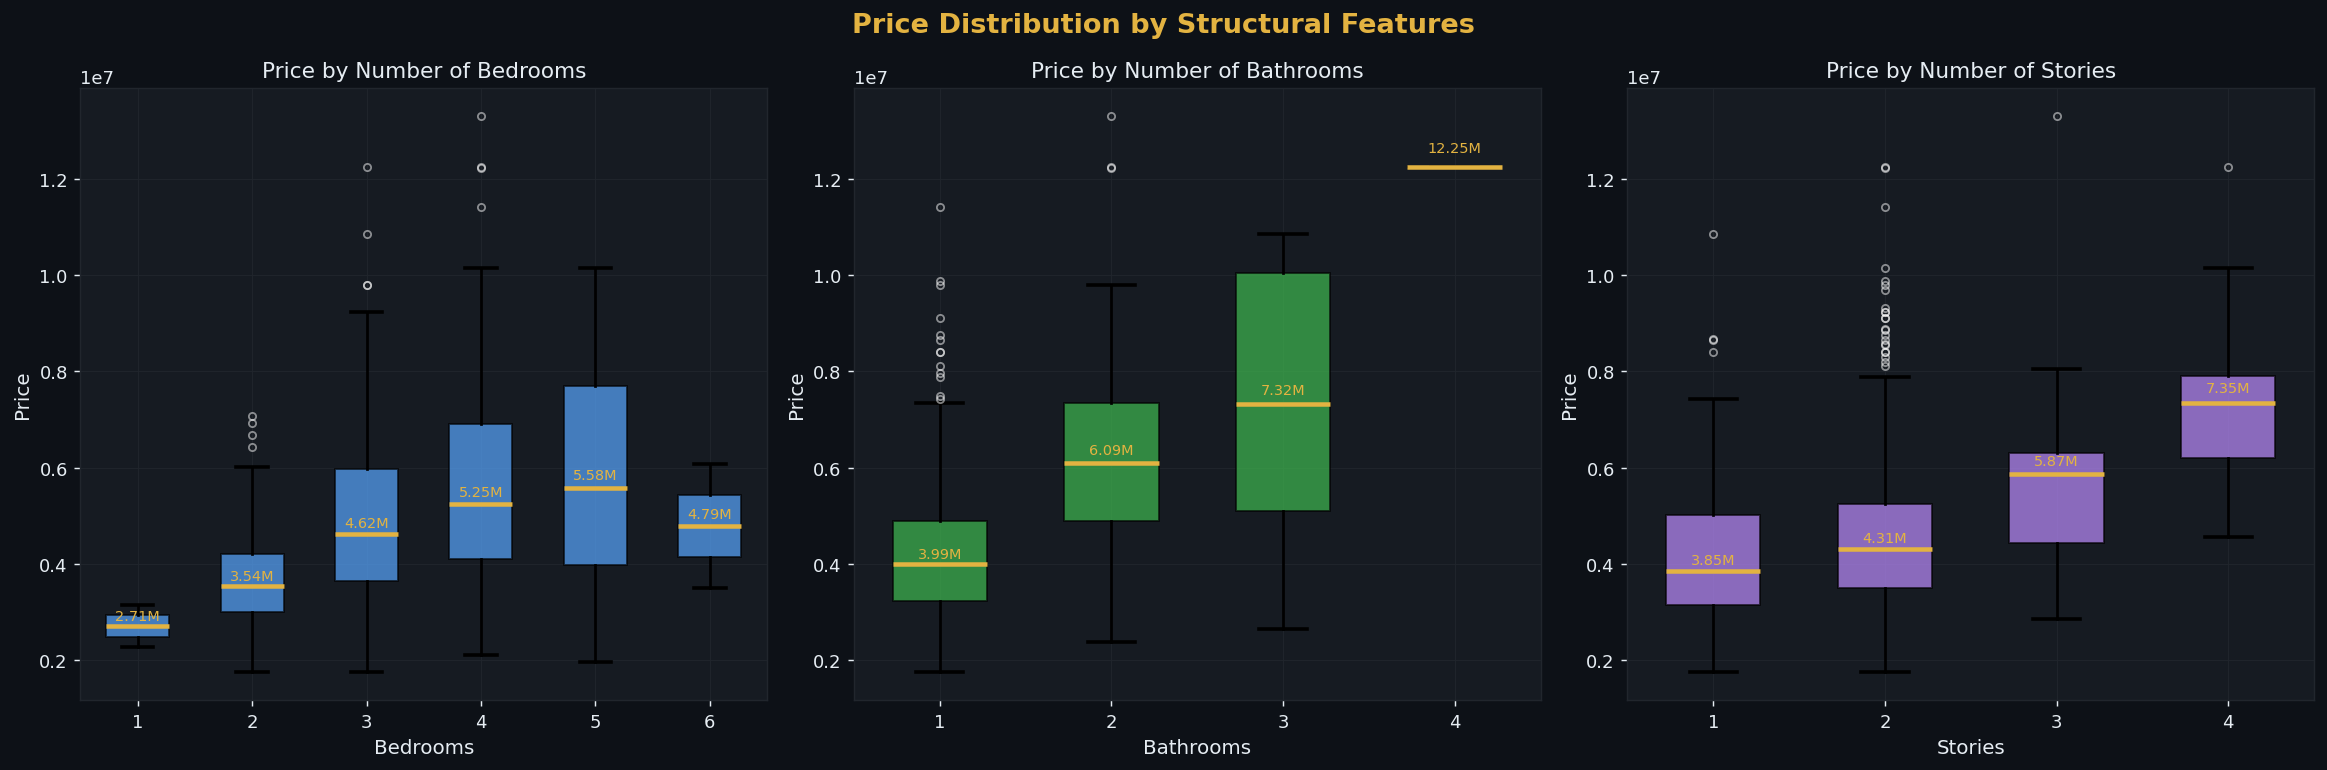

📌 Insight: Price generally rises with bedroom and bathroom count.
   Multi-story homes command a clear premium over single-story properties.


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOTS 5.3, 5.4, 5.5 — PRICE BY BEDROOMS / BATHROOMS / STORIES
# Box plots show the median, spread, and outliers per category.
# Median labels annotated in gold for readability.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Price Distribution by Structural Features',
             fontsize=15, color=GOLD, fontweight='bold')

for ax, feat, color, title in [
    (axes[0], 'bedrooms',  BLUE,   'Price by Number of Bedrooms'),
    (axes[1], 'bathrooms', GREEN,  'Price by Number of Bathrooms'),
    (axes[2], 'stories',   PURPLE, 'Price by Number of Stories'),
]:
    categories  = sorted(df[feat].unique())
    data_groups = [df[df[feat] == c]['price'].values for c in categories]

    bp = ax.boxplot(data_groups, patch_artist=True, notch=False,
                    widths=0.55,
                    medianprops=dict(color=GOLD, linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=2),
                    flierprops=dict(marker='o', markersize=4,
                                   markeredgecolor='white', alpha=0.5))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Annotate median value above each box
    for i, grp in enumerate(data_groups, 1):
        med = np.median(grp)
        ax.text(i, med * 1.02, f'{med/1e6:.2f}M',
                ha='center', va='bottom', fontsize=8, color=GOLD)

    ax.set_xticks(range(1, len(categories) + 1))
    ax.set_xticklabels([str(c) for c in categories])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(feat.capitalize())
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

print('📌 Insight: Price generally rises with bedroom and bathroom count.')
print('   Multi-story homes command a clear premium over single-story properties.')

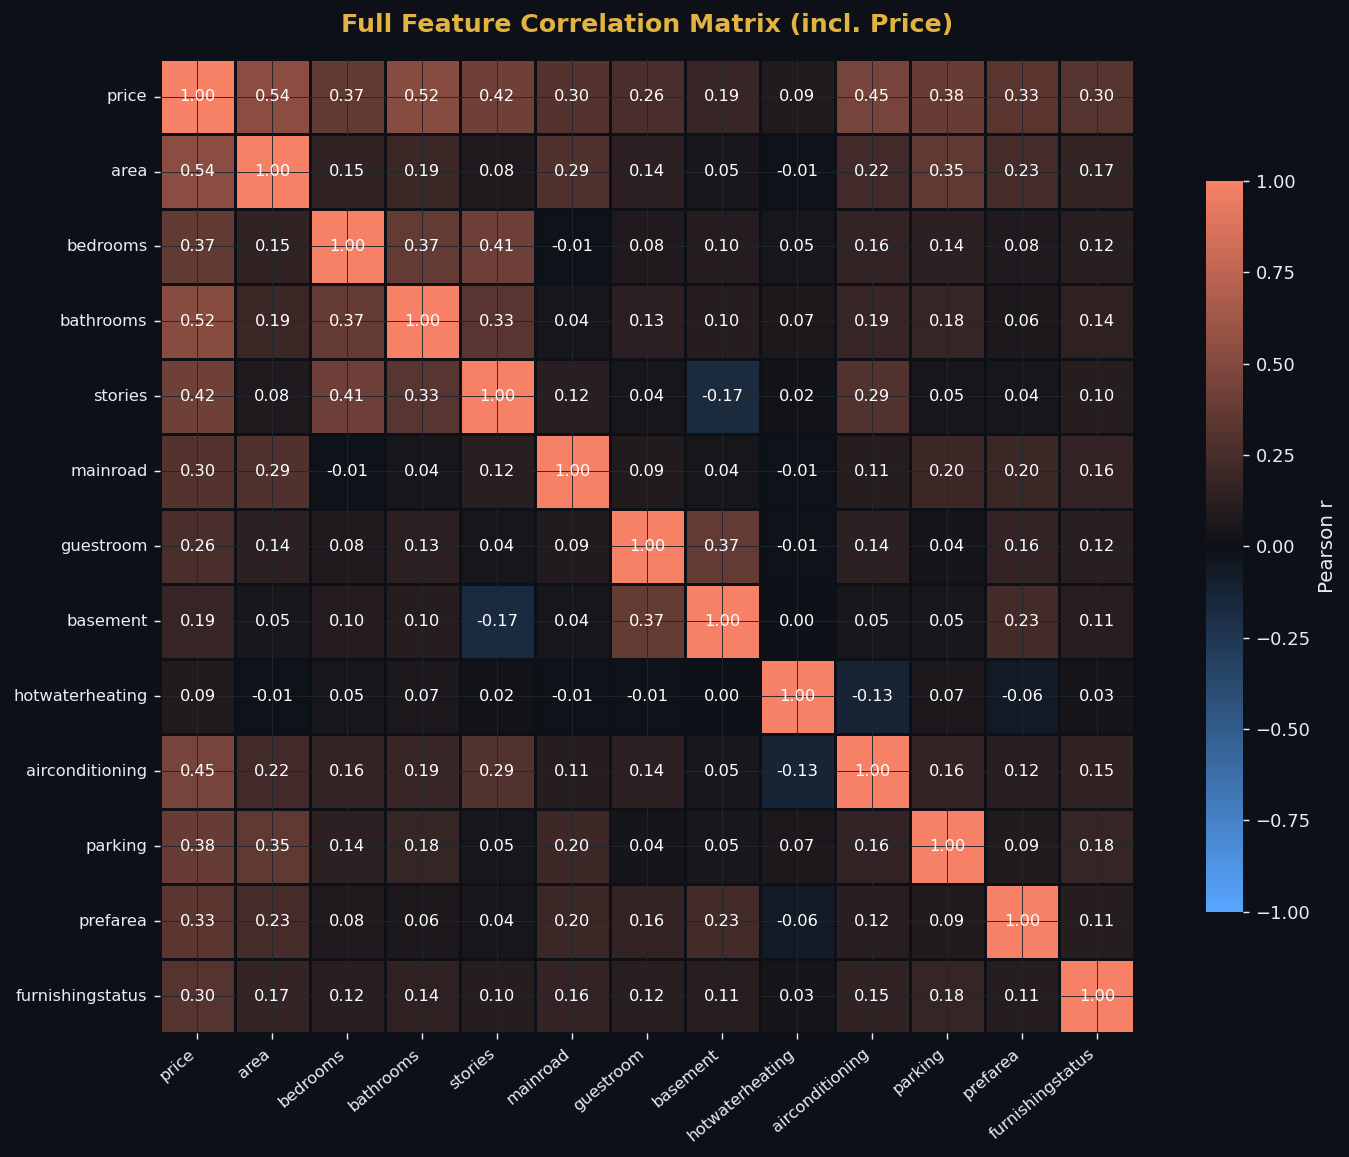

📌 Top features correlated with price (|r|):
   area                : r = +0.536  ↑
   bathrooms           : r = +0.518  ↑
   airconditioning     : r = +0.453  ↑
   stories             : r = +0.421  ↑
   parking             : r = +0.384  ↑
   bedrooms            : r = +0.366  ↑


In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.6 — CORRELATION HEATMAP
# Pearson r between every pair of features including the target (price).
# Lower triangle only — mirrors the style used across all tasks in this project.
# ═════════════════════════════════════════════════════════════════════════════

corr = df.corr()

cmap = LinearSegmentedColormap.from_list(
    'house', ['#58A6FF', '#0D1117', '#F78166'], N=256
)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask=True hides upper triangle → shows lower only

sns.heatmap(
    corr, ax=ax, annot=True, fmt='.2f', cmap=cmap,
    center=0, vmin=-1, vmax=1,
    linewidths=1.5, linecolor=BG,
    annot_kws={'size': 9},
    square=True, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
)
ax.set_title('Full Feature Correlation Matrix (incl. Price)',
             fontsize=14, color=GOLD, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# Print top correlations with price
target_corr = corr['price'].drop('price').abs().sort_values(ascending=False)
print('📌 Top features correlated with price (|r|):')
for feat, val in target_corr.head(6).items():
    direction = '↑' if corr['price'][feat] > 0 else '↓'
    print(f'   {feat:<20}: r = {corr["price"][feat]:+.3f}  {direction}')

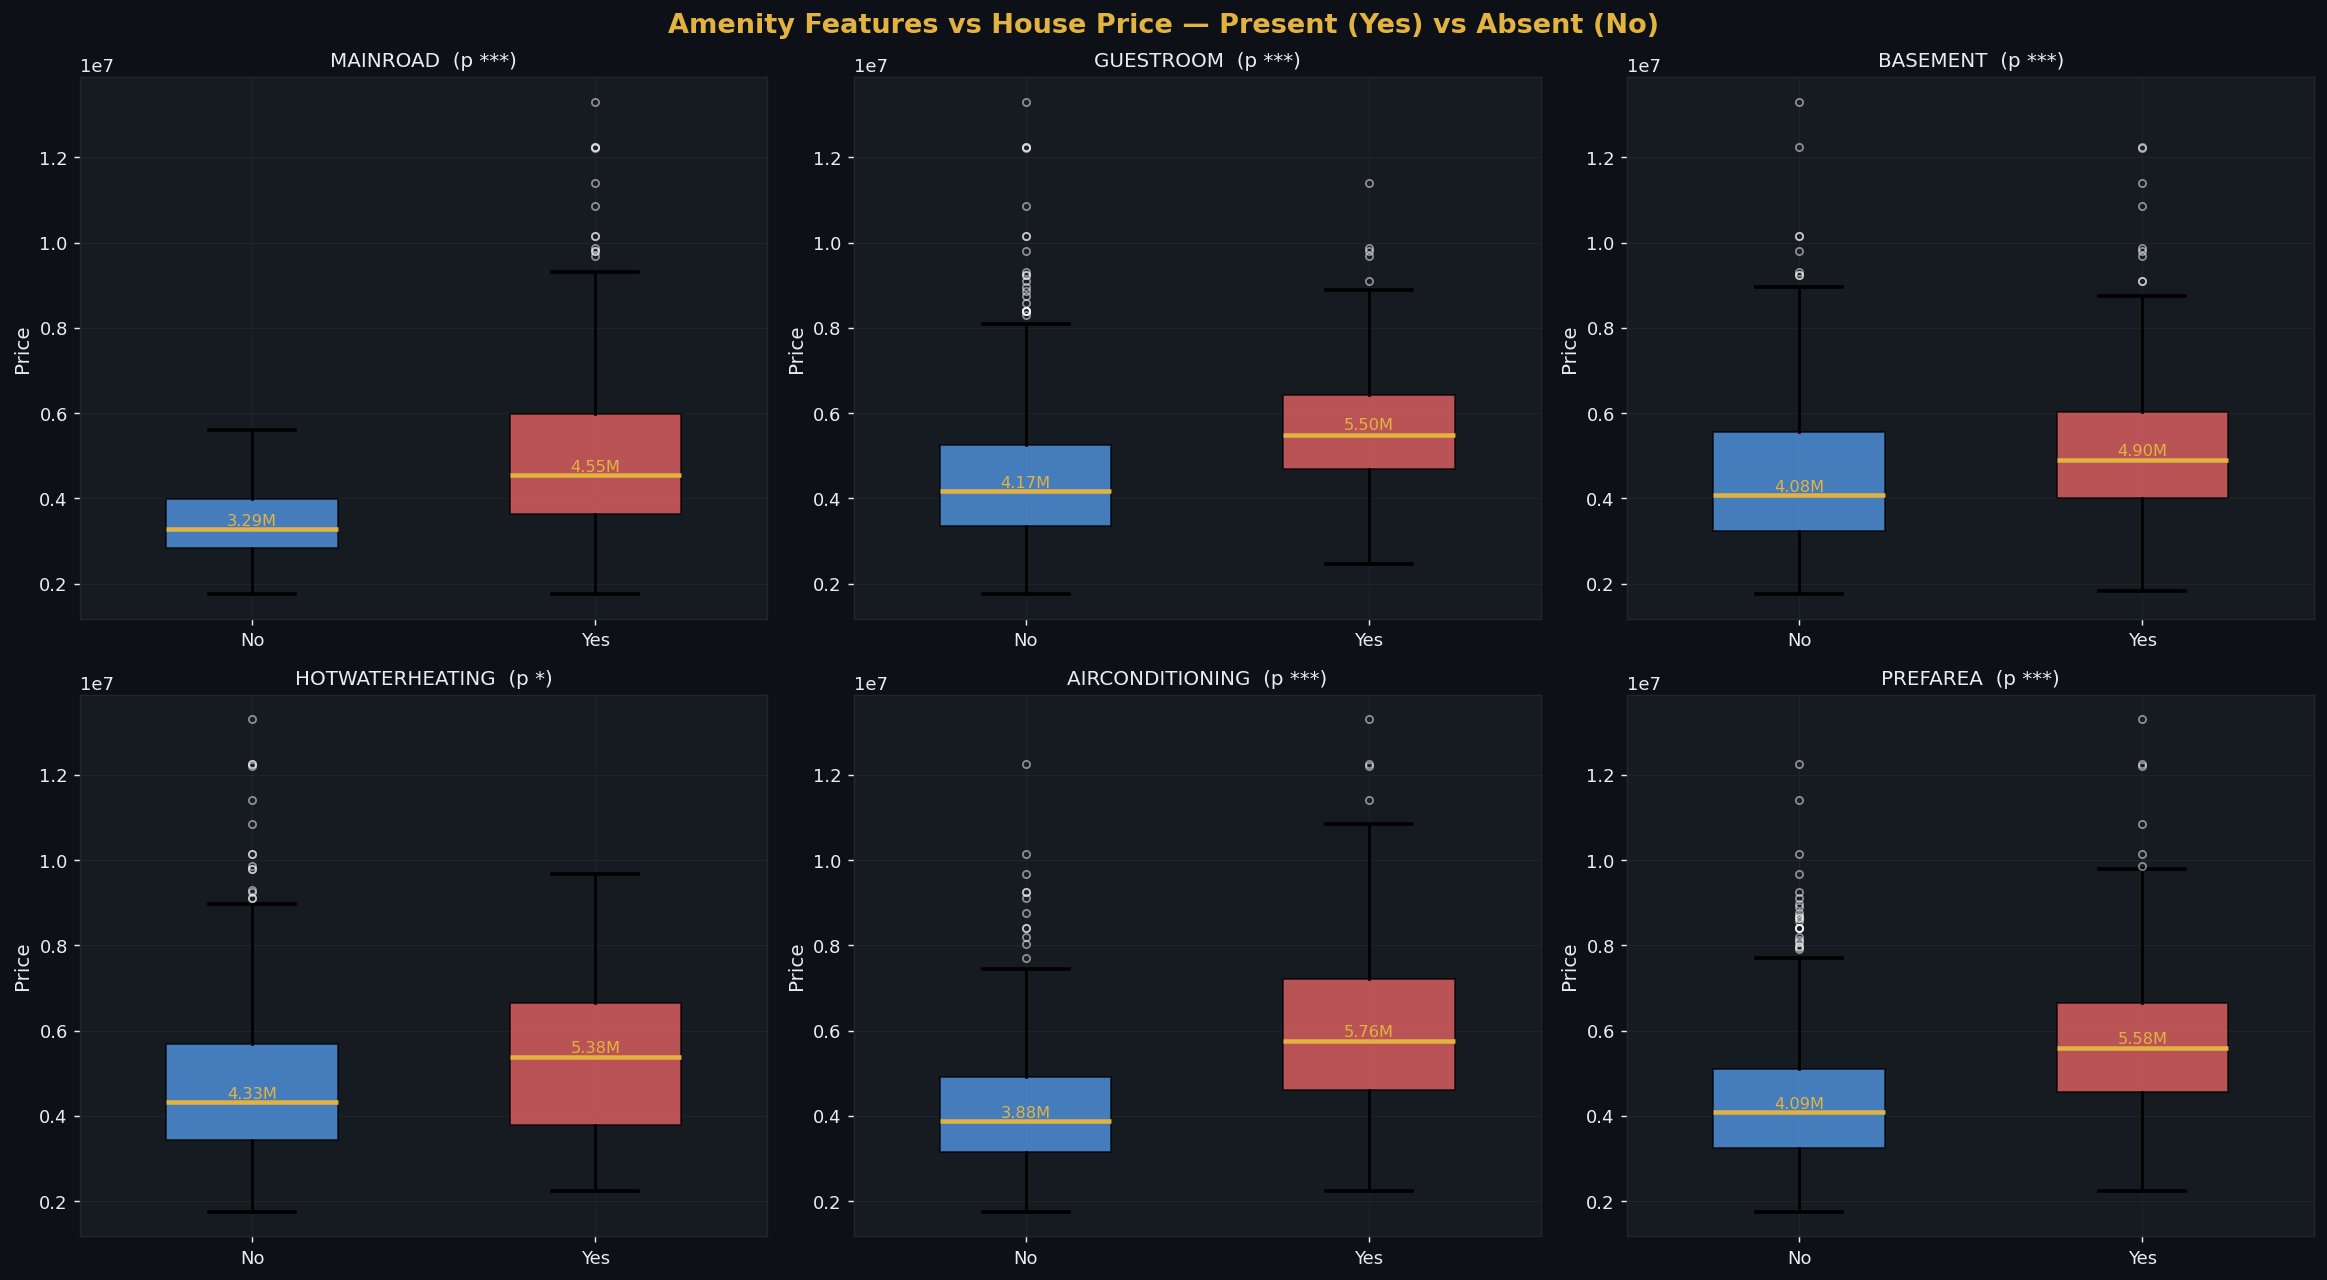

📌 Air conditioning, preferred area, and main road access show the largest price premiums.
   *** = highly significant difference between groups (p < 0.001)


In [10]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.7 — BINARY AMENITY FEATURES vs PRICE
# For each yes/no feature, box plots compare price when present vs absent.
# Mann-Whitney U test determines if the difference is statistically significant.
# ═════════════════════════════════════════════════════════════════════════════

AMENITY_COLS = ['mainroad', 'guestroom', 'basement',
                'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Amenity Features vs House Price — Present (Yes) vs Absent (No)',
             fontsize=15, color=GOLD, fontweight='bold')

for ax, feat in zip(axes.flatten(), AMENITY_COLS):
    groups = [df[df[feat] == v]['price'].values for v in [0, 1]]

    bp = ax.boxplot(groups, patch_artist=True, notch=False, widths=0.5,
                    medianprops=dict(color=GOLD, linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=2),
                    flierprops=dict(marker='o', markersize=4,
                                   markeredgecolor='white', alpha=0.5))
    for patch, color in zip(bp['boxes'], [BLUE, RED]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Annotate medians
    for i, grp in enumerate(groups, 1):
        med = np.median(grp)
        ax.text(i, med * 1.02, f'{med/1e6:.2f}M',
                ha='center', fontsize=9, color=GOLD)

    # Mann-Whitney U significance test
    stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{feat.upper()}  (p {sig})', fontsize=11)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()
print('📌 Air conditioning, preferred area, and main road access show the largest price premiums.')
print('   *** = highly significant difference between groups (p < 0.001)')

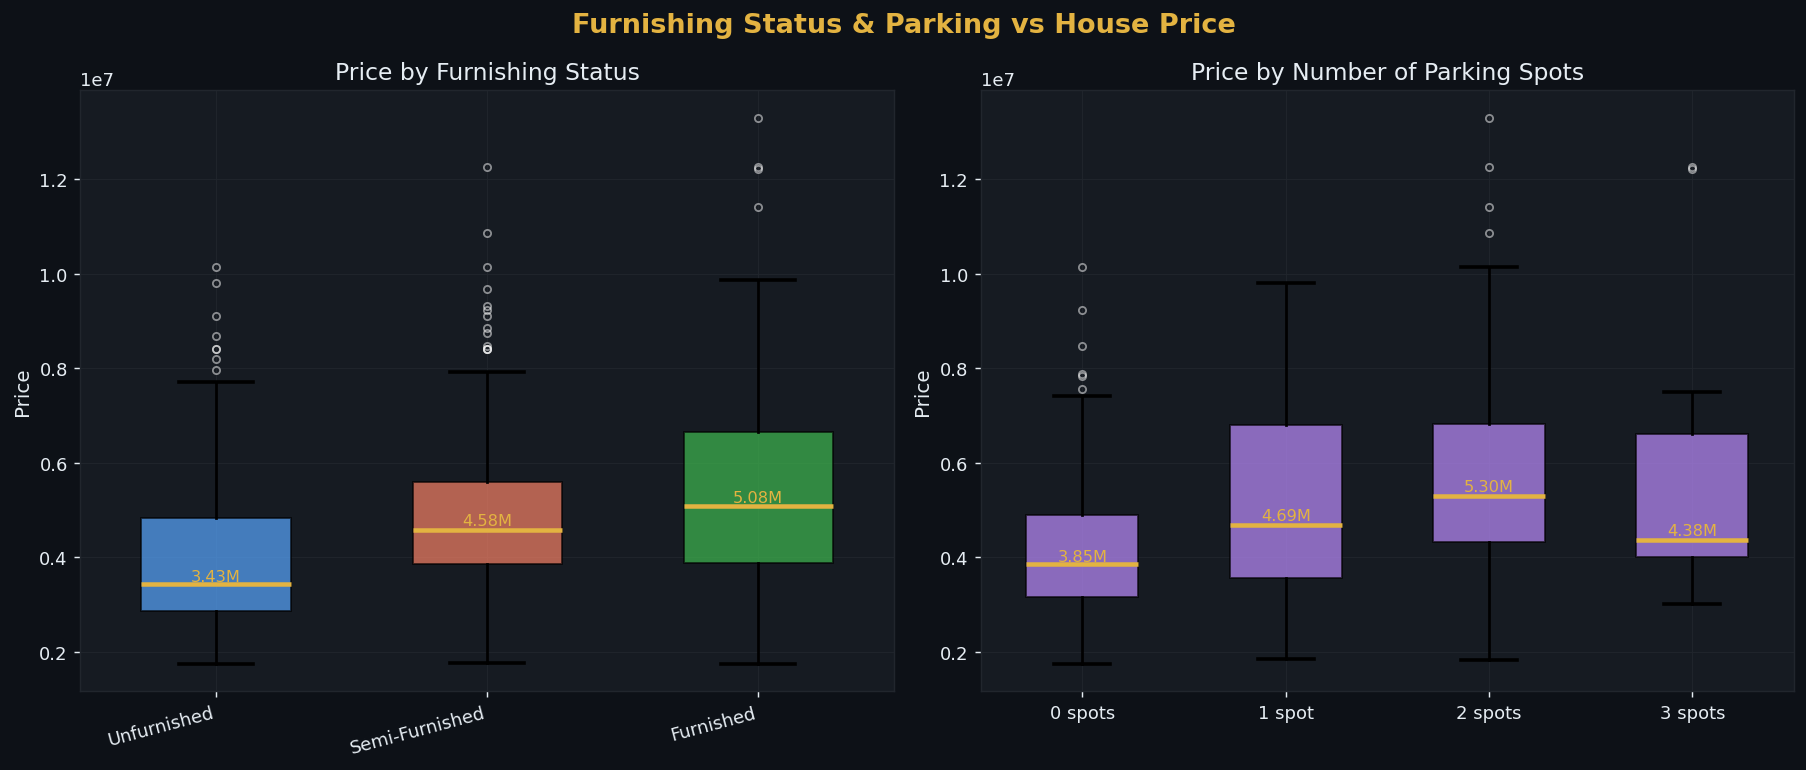

📌 Furnished homes sell for significantly more than unfurnished ones.
   More parking spots correlate with higher property values.


In [11]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.8 — PRICE BY FURNISHING STATUS
# PLOT 5.9 — PRICE BY PARKING SPOTS
# ═════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Furnishing Status & Parking vs House Price',
             fontsize=15, color=GOLD, fontweight='bold')

# ── Furnishing status (0=unfurnished, 1=semi, 2=furnished) ──
furn_labels = {0: 'Unfurnished', 1: 'Semi-Furnished', 2: 'Furnished'}
furn_colors = [BLUE, ORANGE, GREEN]
furn_cats   = sorted(df['furnishingstatus'].unique())
furn_groups = [df[df['furnishingstatus'] == c]['price'].values for c in furn_cats]

bp1 = ax1.boxplot(furn_groups, patch_artist=True, notch=False, widths=0.55,
                  medianprops=dict(color=GOLD, linewidth=2.5),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=2),
                  flierprops=dict(marker='o', markersize=4,
                                 markeredgecolor='white', alpha=0.5))
for patch, color in zip(bp1['boxes'], furn_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, grp in enumerate(furn_groups, 1):
    med = np.median(grp)
    ax1.text(i, med * 1.02, f'{med/1e6:.2f}M', ha='center', fontsize=9, color=GOLD)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels([furn_labels[c] for c in furn_cats], rotation=15, ha='right')
ax1.set_title('Price by Furnishing Status')
ax1.set_ylabel('Price')

# ── Parking spots ──
park_cats   = sorted(df['parking'].unique())
park_groups = [df[df['parking'] == c]['price'].values for c in park_cats]

bp2 = ax2.boxplot(park_groups, patch_artist=True, notch=False, widths=0.55,
                  medianprops=dict(color=GOLD, linewidth=2.5),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=2),
                  flierprops=dict(marker='o', markersize=4,
                                 markeredgecolor='white', alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor(PURPLE); patch.set_alpha(0.7)
for i, grp in enumerate(park_groups, 1):
    med = np.median(grp)
    ax2.text(i, med * 1.02, f'{med/1e6:.2f}M', ha='center', fontsize=9, color=GOLD)
ax2.set_xticks(range(1, len(park_cats) + 1))
ax2.set_xticklabels([f'{c} spot{"s" if c != 1 else ""}' for c in park_cats])
ax2.set_title('Price by Number of Parking Spots')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()
print('📌 Furnished homes sell for significantly more than unfurnished ones.')
print('   More parking spots correlate with higher property values.')

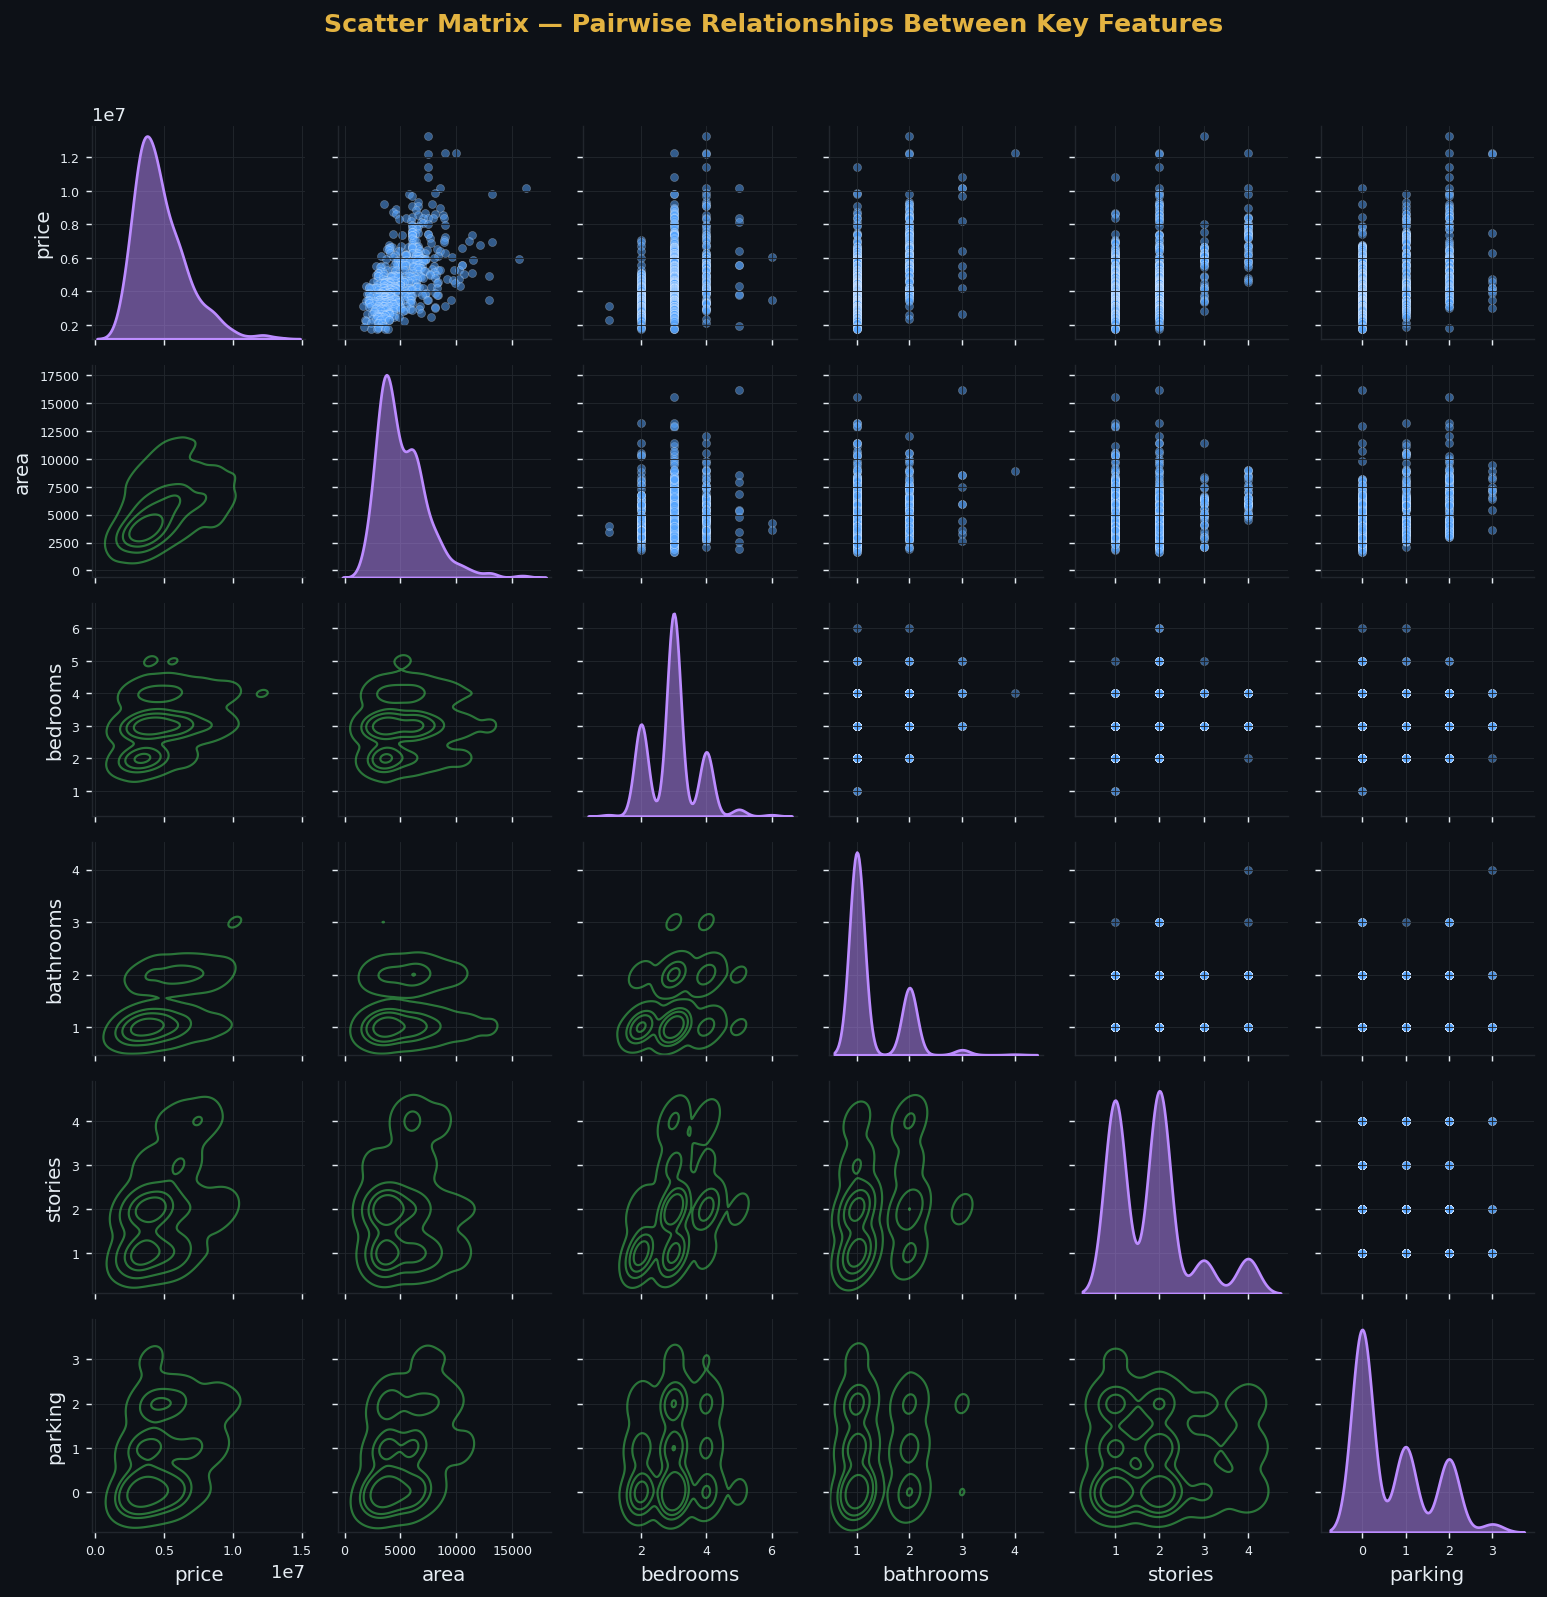

📌 Area has the clearest linear relationship with price among all numeric features.
   Bedroom and bathroom counts show step-wise increases rather than smooth trends.


In [12]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 5.10 — SCATTER MATRIX (Pairwise Relationships)
# Upper triangle: scatter plots. Diagonal: KDE. Lower: 2D density contours.
# ═════════════════════════════════════════════════════════════════════════════

top_numeric = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
pair_df = df[top_numeric].copy()

g = sns.PairGrid(pair_df, diag_sharey=False, height=2.0)
g.map_upper(sns.scatterplot, alpha=0.5, s=20, color=BLUE,
            edgecolor='white', linewidth=0.2)
g.map_diag(sns.kdeplot, fill=True, color=PURPLE, alpha=0.5, linewidth=1.5)
g.map_lower(sns.kdeplot, levels=5, alpha=0.6, color=GREEN, linewidths=1.2)

g.figure.set_facecolor(BG)
for ax in g.axes.flatten():
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT, labelsize=7)

g.figure.suptitle(
    'Scatter Matrix — Pairwise Relationships Between Key Features',
    y=1.02, fontsize=14, color=GOLD, fontweight='bold'
)
plt.tight_layout()
plt.show()
print('📌 Area has the clearest linear relationship with price among all numeric features.')
print('   Bedroom and bathroom counts show step-wise increases rather than smooth trends.')

## Step 6 — Feature Engineering & Train/Test Split

We add three engineered features capturing combined value signals:

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `total_rooms` | bedrooms + bathrooms | Overall living capacity |
| `luxury_score` | sum of 5 premium amenities | Composite affluence indicator |
| `area_per_room` | area ÷ (total_rooms + 1) | Space efficiency per room |

An 80/20 train/test split is applied. Features are scaled for Linear Regression (scale-sensitive); Gradient Boosting receives raw features (scale-invariant trees).

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

df_model = df.copy()

# 1. Total rooms — combined living capacity
df_model['total_rooms'] = df_model['bedrooms'] + df_model['bathrooms']

# 2. Luxury score — count of premium amenities present
df_model['luxury_score'] = (df_model['airconditioning'] +
                             df_model['prefarea']        +
                             df_model['guestroom']       +
                             df_model['basement']        +
                             df_model['hotwaterheating'])

# 3. Area per room — space efficiency indicator
df_model['area_per_room'] = df_model['area'] / (df_model['total_rooms'] + 1)

FEATURE_COLS = [c for c in df_model.columns if c != 'price']
X = df_model[FEATURE_COLS]
y = df_model['price']

# ── 80/20 Train/Test Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── Feature Scaling (fit ONLY on train — prevents data leakage) ───────────
scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train),
                         columns=FEATURE_COLS, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),
                         columns=FEATURE_COLS, index=X_test.index)

print('✅ Feature engineering complete.')
print(f'   Features ({len(FEATURE_COLS)} total): {FEATURE_COLS}')
print(f'\n   Train samples : {len(X_train)}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Test  samples : {len(X_test)}  ({len(X_test)/len(df)*100:.0f}%)')

✅ Feature engineering complete.
   Features (15 total): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'total_rooms', 'luxury_score', 'area_per_room']

   Train samples : 436  (80%)
   Test  samples : 109  (20%)


## Step 7 — Model Training

We train two regression models:

| Model | Strengths | Notes |
|-------|-----------|-------|
| **Linear Regression** | Fast, interpretable, clinically transparent baseline | Uses scaled features |
| **Gradient Boosting** | Handles non-linearity and feature interactions; results vary by dataset size | Uses raw features |

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN BOTH MODELS
# ─────────────────────────────────────────────────────────────────────────────

# ── Model 1: Linear Regression (scaled features) ──────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
print(f'  ✅ Linear Regression     | Test R²: {r2_score(y_test, lr_pred):.4f}')

# ── Model 2: Gradient Boosting Regressor (raw features) ───────────────────
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.85,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print(f'  ✅ Gradient Boosting     | Test R²: {r2_score(y_test, gb_pred):.4f}')

print('\n🏆 Both models trained successfully.')

  ✅ Linear Regression     | Test R²: 0.6552
  ✅ Gradient Boosting     | Test R²: 0.6012

🏆 Both models trained successfully.


## Step 8 — Model Evaluation

We evaluate using four regression metrics:

| Metric | What It Measures |
|--------|-----------------|
| **MAE** | Average absolute error — easy to interpret in price units |
| **RMSE** | Square-root of mean squared error — penalises large errors more |
| **MAPE** | Mean absolute % error — scale-independent, comparable across datasets |
| **R²** | Proportion of variance explained — 1.0 = perfect, 0 = baseline mean |

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE & DISPLAY EVALUATION METRICS
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(y_true, y_pred, name):
    """Compute MAE, RMSE, MAPE, and R² for a regression model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}

metrics_df = pd.DataFrame([
    evaluate_model(y_test, lr_pred, 'Linear Regression'),
    evaluate_model(y_test, gb_pred, 'Gradient Boosting'),
]).set_index('Model')

print('═' * 65)
print('              MODEL PERFORMANCE COMPARISON')
print('═' * 65)
print(metrics_df.round(4).to_string())
print('═' * 65)

best_model_name = metrics_df['R²'].idxmax()
print(f'\n🏆 Best model by R²: {best_model_name}  (R² = {metrics_df.loc[best_model_name, "R²"]:.4f})')

═════════════════════════════════════════════════════════════════
              MODEL PERFORMANCE COMPARISON
═════════════════════════════════════════════════════════════════
                            MAE          RMSE  MAPE (%)      R²
Model                                                          
Linear Regression  9.749961e+05  1.320172e+06   21.2135  0.6552
Gradient Boosting  1.023189e+06  1.419796e+06   21.7443  0.6012
═════════════════════════════════════════════════════════════════

🏆 Best model by R²: Linear Regression  (R² = 0.6552)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD CROSS-VALIDATION — checks generalization, detects overfitting
# ─────────────────────────────────────────────────────────────────────────────

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = -cross_val_score(lr, X_train_s, y_train,
                          cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gb_cv = -cross_val_score(gb, X_train,   y_train,
                          cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

print('5-Fold Cross-Validation MAE:')
print(f'  Linear Regression : {lr_cv.mean():,.0f}  ±  {lr_cv.std():,.0f}')
print(f'  Gradient Boosting : {gb_cv.mean():,.0f}  ±  {gb_cv.std():,.0f}')
print('\n📌 Lower MAE and lower std = better generalization to unseen data.')

5-Fold Cross-Validation MAE:
  Linear Regression : 740,608  ±  40,829
  Gradient Boosting : 747,862  ±  48,606

📌 Lower MAE and lower std = better generalization to unseen data.


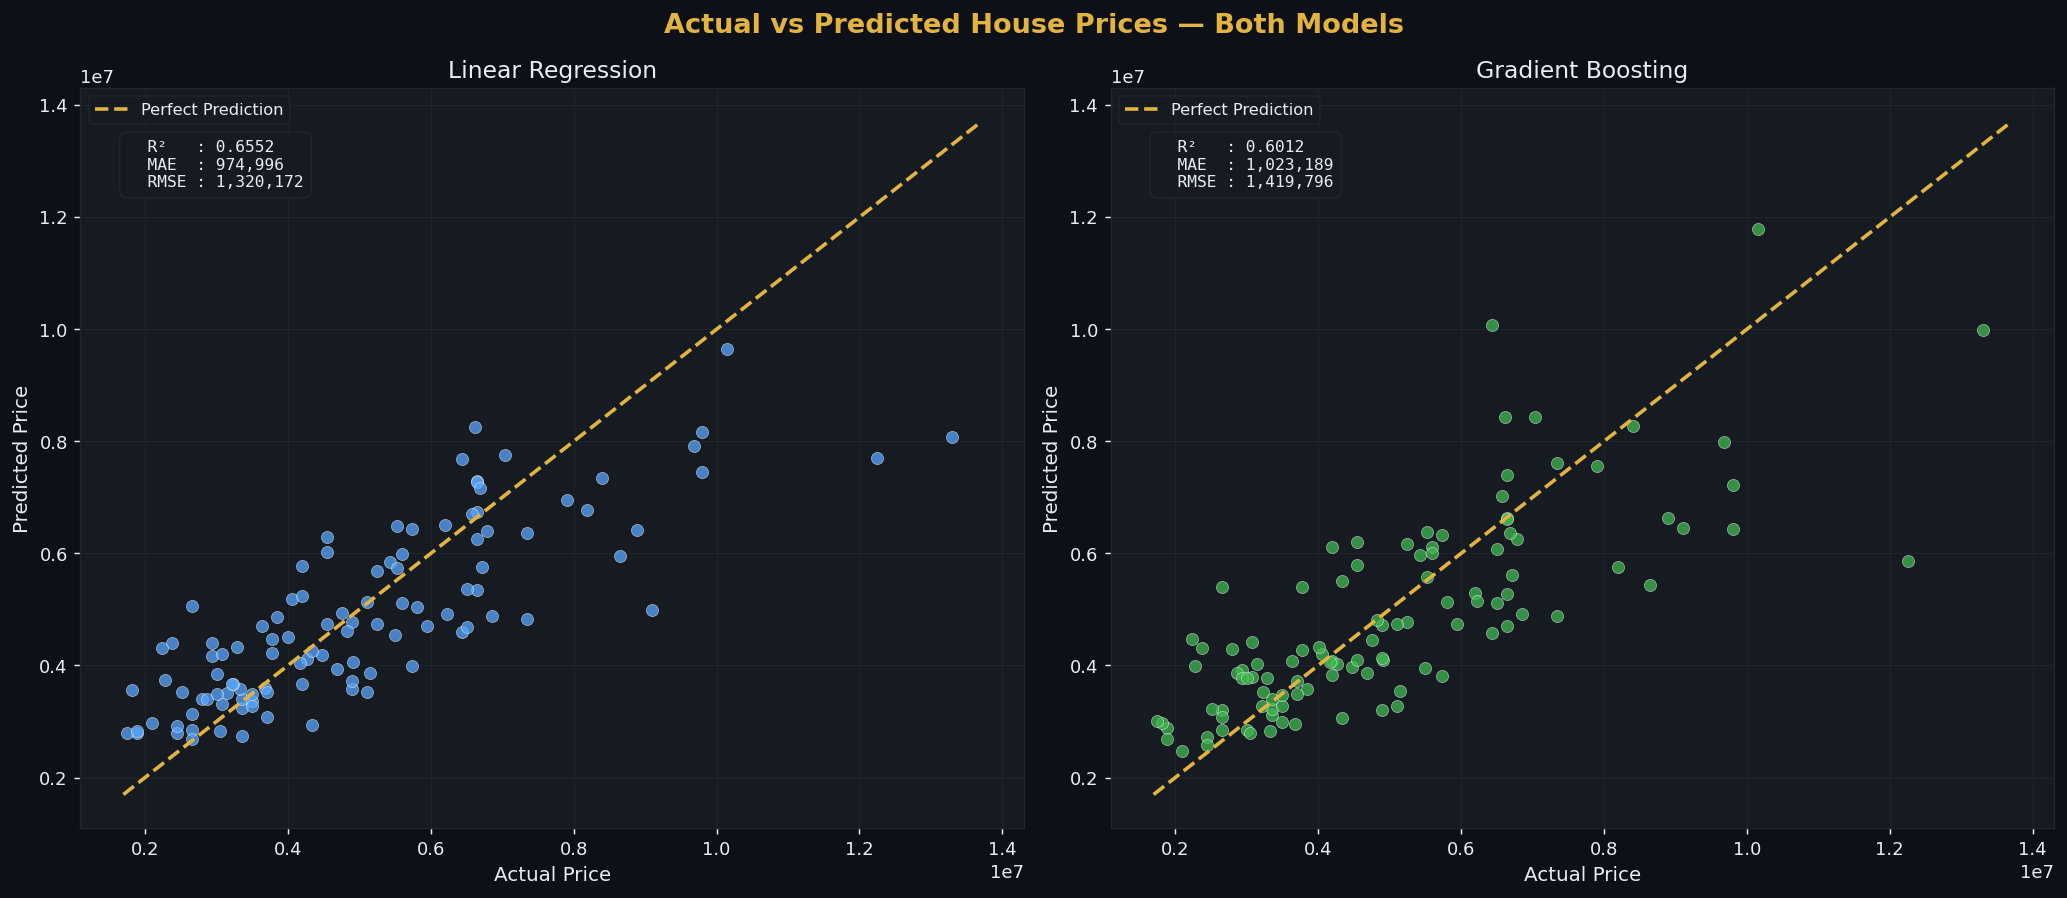

📌 Points close to the diagonal = accurate predictions.
   Linear Regression shows a tighter cluster on this dataset.


In [17]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE — ACTUAL vs PREDICTED (Main Visual Comparison)
# Points close to the gold diagonal = accurate predictions.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Actual vs Predicted House Prices — Both Models',
             fontsize=15, color=GOLD, fontweight='bold')

all_vals = np.concatenate([y_test.values, lr_pred, gb_pred])
lo = all_vals.min() * 0.97
hi = all_vals.max() * 1.03

for ax, (name, preds, color) in zip(axes, [
    ('Linear Regression', lr_pred, BLUE),
    ('Gradient Boosting', gb_pred, GREEN),
]):
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    ax.scatter(y_test, preds, c=color, s=45, alpha=0.75,
               edgecolors='white', linewidths=0.3, zorder=3)
    ax.plot([lo, hi], [lo, hi], color=GOLD, lw=2, linestyle='--',
            label='Perfect Prediction', zorder=5)

    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}', fontsize=13)
    ax.legend(fontsize=9)

    # Metric box
    textstr = (f'  R²   : {r2:.4f}\n'
               f'  MAE  : {mae:,.0f}\n'
               f'  RMSE : {rmse:,.0f}')
    props = dict(boxstyle='round,pad=0.5', facecolor=PANEL,
                 alpha=0.9, edgecolor=GRID)
    ax.text(0.05, 0.93, textstr, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=props, color=TEXT, family='monospace')

plt.tight_layout()
plt.show()
print('📌 Points close to the diagonal = accurate predictions.')
print('   Linear Regression shows a tighter cluster on this dataset.')

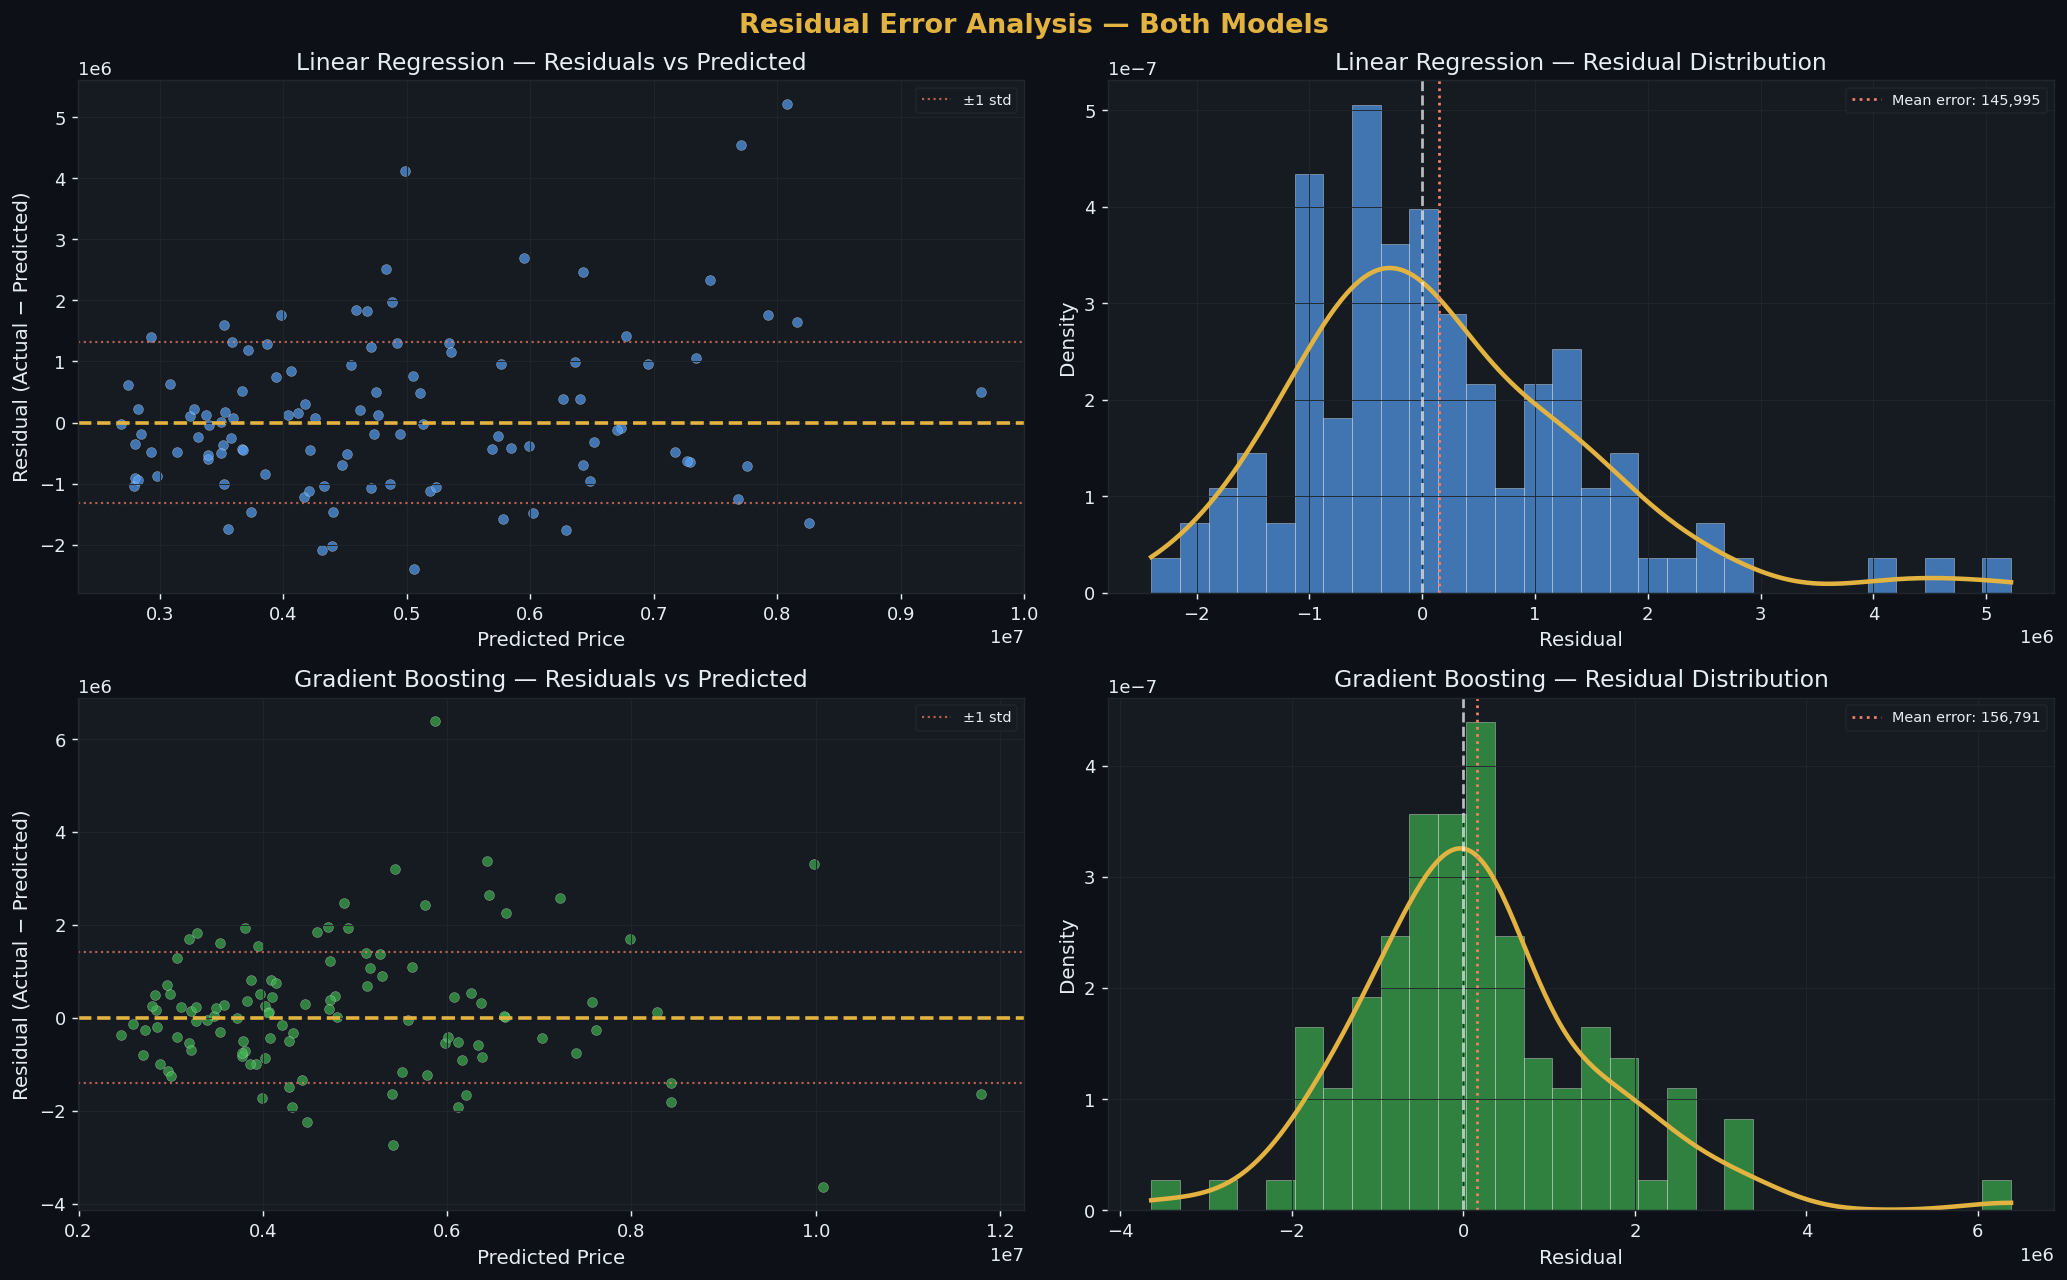

📌 Ideal residuals: randomly scattered around 0 with a normal distribution.
   A funnel pattern would indicate variance growing with price (heteroscedasticity).


In [18]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE — RESIDUAL ERROR ANALYSIS (Both Models)
# Residuals vs Predicted: checks for patterns (funnel = heteroscedasticity).
# Residual distribution: should be approximately normal and centred at 0.
# ═════════════════════════════════════════════════════════════════════════════

lr_resid = y_test.values - lr_pred
gb_resid = y_test.values - gb_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Residual Error Analysis — Both Models',
             fontsize=15, color=GOLD, fontweight='bold')

for (ax_res, ax_dist), (name, preds, resid, color) in zip(
    [(axes[0, 0], axes[0, 1]),
     (axes[1, 0], axes[1, 1])],
    [('Linear Regression', lr_pred, lr_resid, BLUE),
     ('Gradient Boosting', gb_pred, gb_resid, GREEN)]
):
    # ── Residuals vs Predicted ──
    ax_res.scatter(preds, resid, c=color, s=30, alpha=0.65,
                   edgecolors='white', linewidths=0.2)
    ax_res.axhline(0,            color=GOLD,   lw=2,   linestyle='--')
    ax_res.axhline( resid.std(), color=ORANGE, lw=1.2, linestyle=':', alpha=0.7, label='±1 std')
    ax_res.axhline(-resid.std(), color=ORANGE, lw=1.2, linestyle=':', alpha=0.7)
    ax_res.set_xlabel('Predicted Price')
    ax_res.set_ylabel('Residual (Actual − Predicted)')
    ax_res.set_title(f'{name} — Residuals vs Predicted')
    ax_res.legend(fontsize=8)

    # ── Residual Distribution ──
    ax_dist.hist(resid, bins=30, color=color, alpha=0.65, density=True,
                 edgecolor='white', linewidth=0.3)
    kx = np.linspace(resid.min(), resid.max(), 300)
    ax_dist.plot(kx, gaussian_kde(resid)(kx), color=GOLD, lw=2.5)
    ax_dist.axvline(0,            color='white', lw=1.5, linestyle='--', alpha=0.7)
    ax_dist.axvline(resid.mean(), color=ORANGE, lw=1.5, linestyle=':',
                    label=f'Mean error: {resid.mean():,.0f}')
    ax_dist.set_xlabel('Residual')
    ax_dist.set_ylabel('Density')
    ax_dist.set_title(f'{name} — Residual Distribution')
    ax_dist.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('📌 Ideal residuals: randomly scattered around 0 with a normal distribution.')
print('   A funnel pattern would indicate variance growing with price (heteroscedasticity).')

## Step 9 — Feature Importance Analysis

We use three independent methods to identify the most influential predictors:

1. **Linear Regression** — absolute coefficient values (on scaled features)
2. **Gradient Boosting MDI** — mean decrease in impurity across all trees
3. **Permutation Importance** — model-agnostic; most statistically reliable

Engineered features (`total_rooms`, `luxury_score`, `area_per_room`) are highlighted in gold.

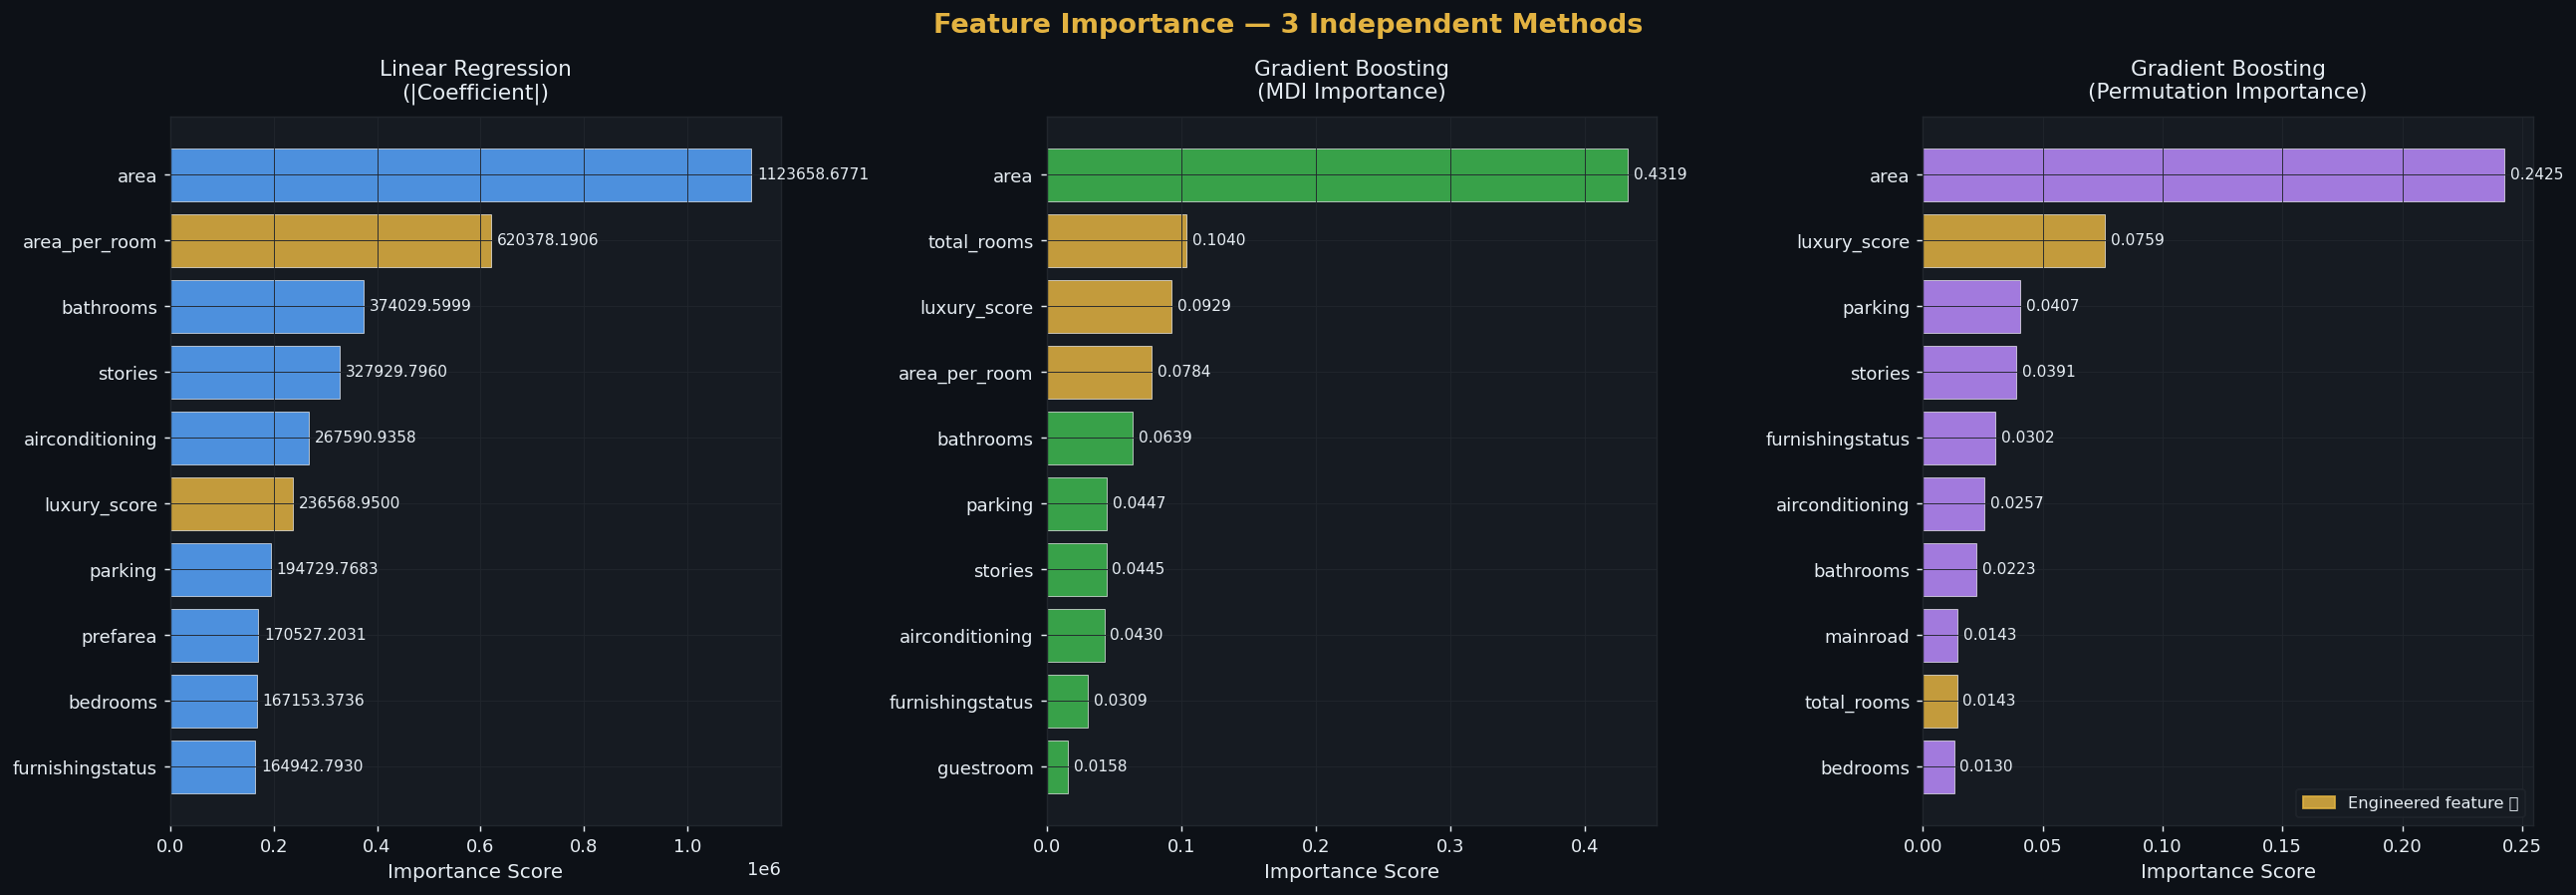

📌 Consensus top features (appear in top-5 of at least 2 methods):
   ['area', 'area_per_room', 'bathrooms', 'luxury_score', 'stories']


In [19]:
# ═════════════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE — 3 Independent Methods
# ═════════════════════════════════════════════════════════════════════════════

# 1. Linear Regression absolute coefficients (scaled features)
lr_coef  = pd.Series(np.abs(lr.coef_),
                     index=FEATURE_COLS).sort_values(ascending=True)

# 2. Gradient Boosting MDI importance
gb_imp   = pd.Series(gb.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=True)

# 3. Permutation importance on Gradient Boosting (X_test, unscaled)
perm = permutation_importance(gb, X_test, y_test,
                               n_repeats=30, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean,
                     index=FEATURE_COLS).sort_values(ascending=True)

ENGINEERED = ['total_rooms', 'luxury_score', 'area_per_room']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Feature Importance — 3 Independent Methods',
             fontsize=15, color=GOLD, fontweight='bold')

for ax, imp, title, base_color in [
    (axes[0], lr_coef,  'Linear Regression\n(|Coefficient|)',         BLUE),
    (axes[1], gb_imp,   'Gradient Boosting\n(MDI Importance)',         GREEN),
    (axes[2], perm_imp, 'Gradient Boosting\n(Permutation Importance)', PURPLE),
]:
    top = imp.tail(10)
    bar_colors = [GOLD if f in ENGINEERED else base_color for f in top.index]
    bars = ax.barh(top.index, top.values, color=bar_colors,
                   edgecolor='white', linewidth=0.4, alpha=0.85)
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + top.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5, color=TEXT)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Importance Score')

gold_patch = mpatches.Patch(color=GOLD, alpha=0.85, label='Engineered feature ⭐')
axes[2].legend(handles=[gold_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# Consensus top features across all 3 methods
top_lr   = set(lr_coef.tail(5).index)
top_gb   = set(gb_imp.tail(5).index)
top_perm = set(perm_imp.tail(5).index)
consensus = (top_lr & top_gb) | (top_lr & top_perm) | (top_gb & top_perm)
print('📌 Consensus top features (appear in top-5 of at least 2 methods):')
print(f'   {sorted(consensus)}')

## Step 10 — Summary Dashboard

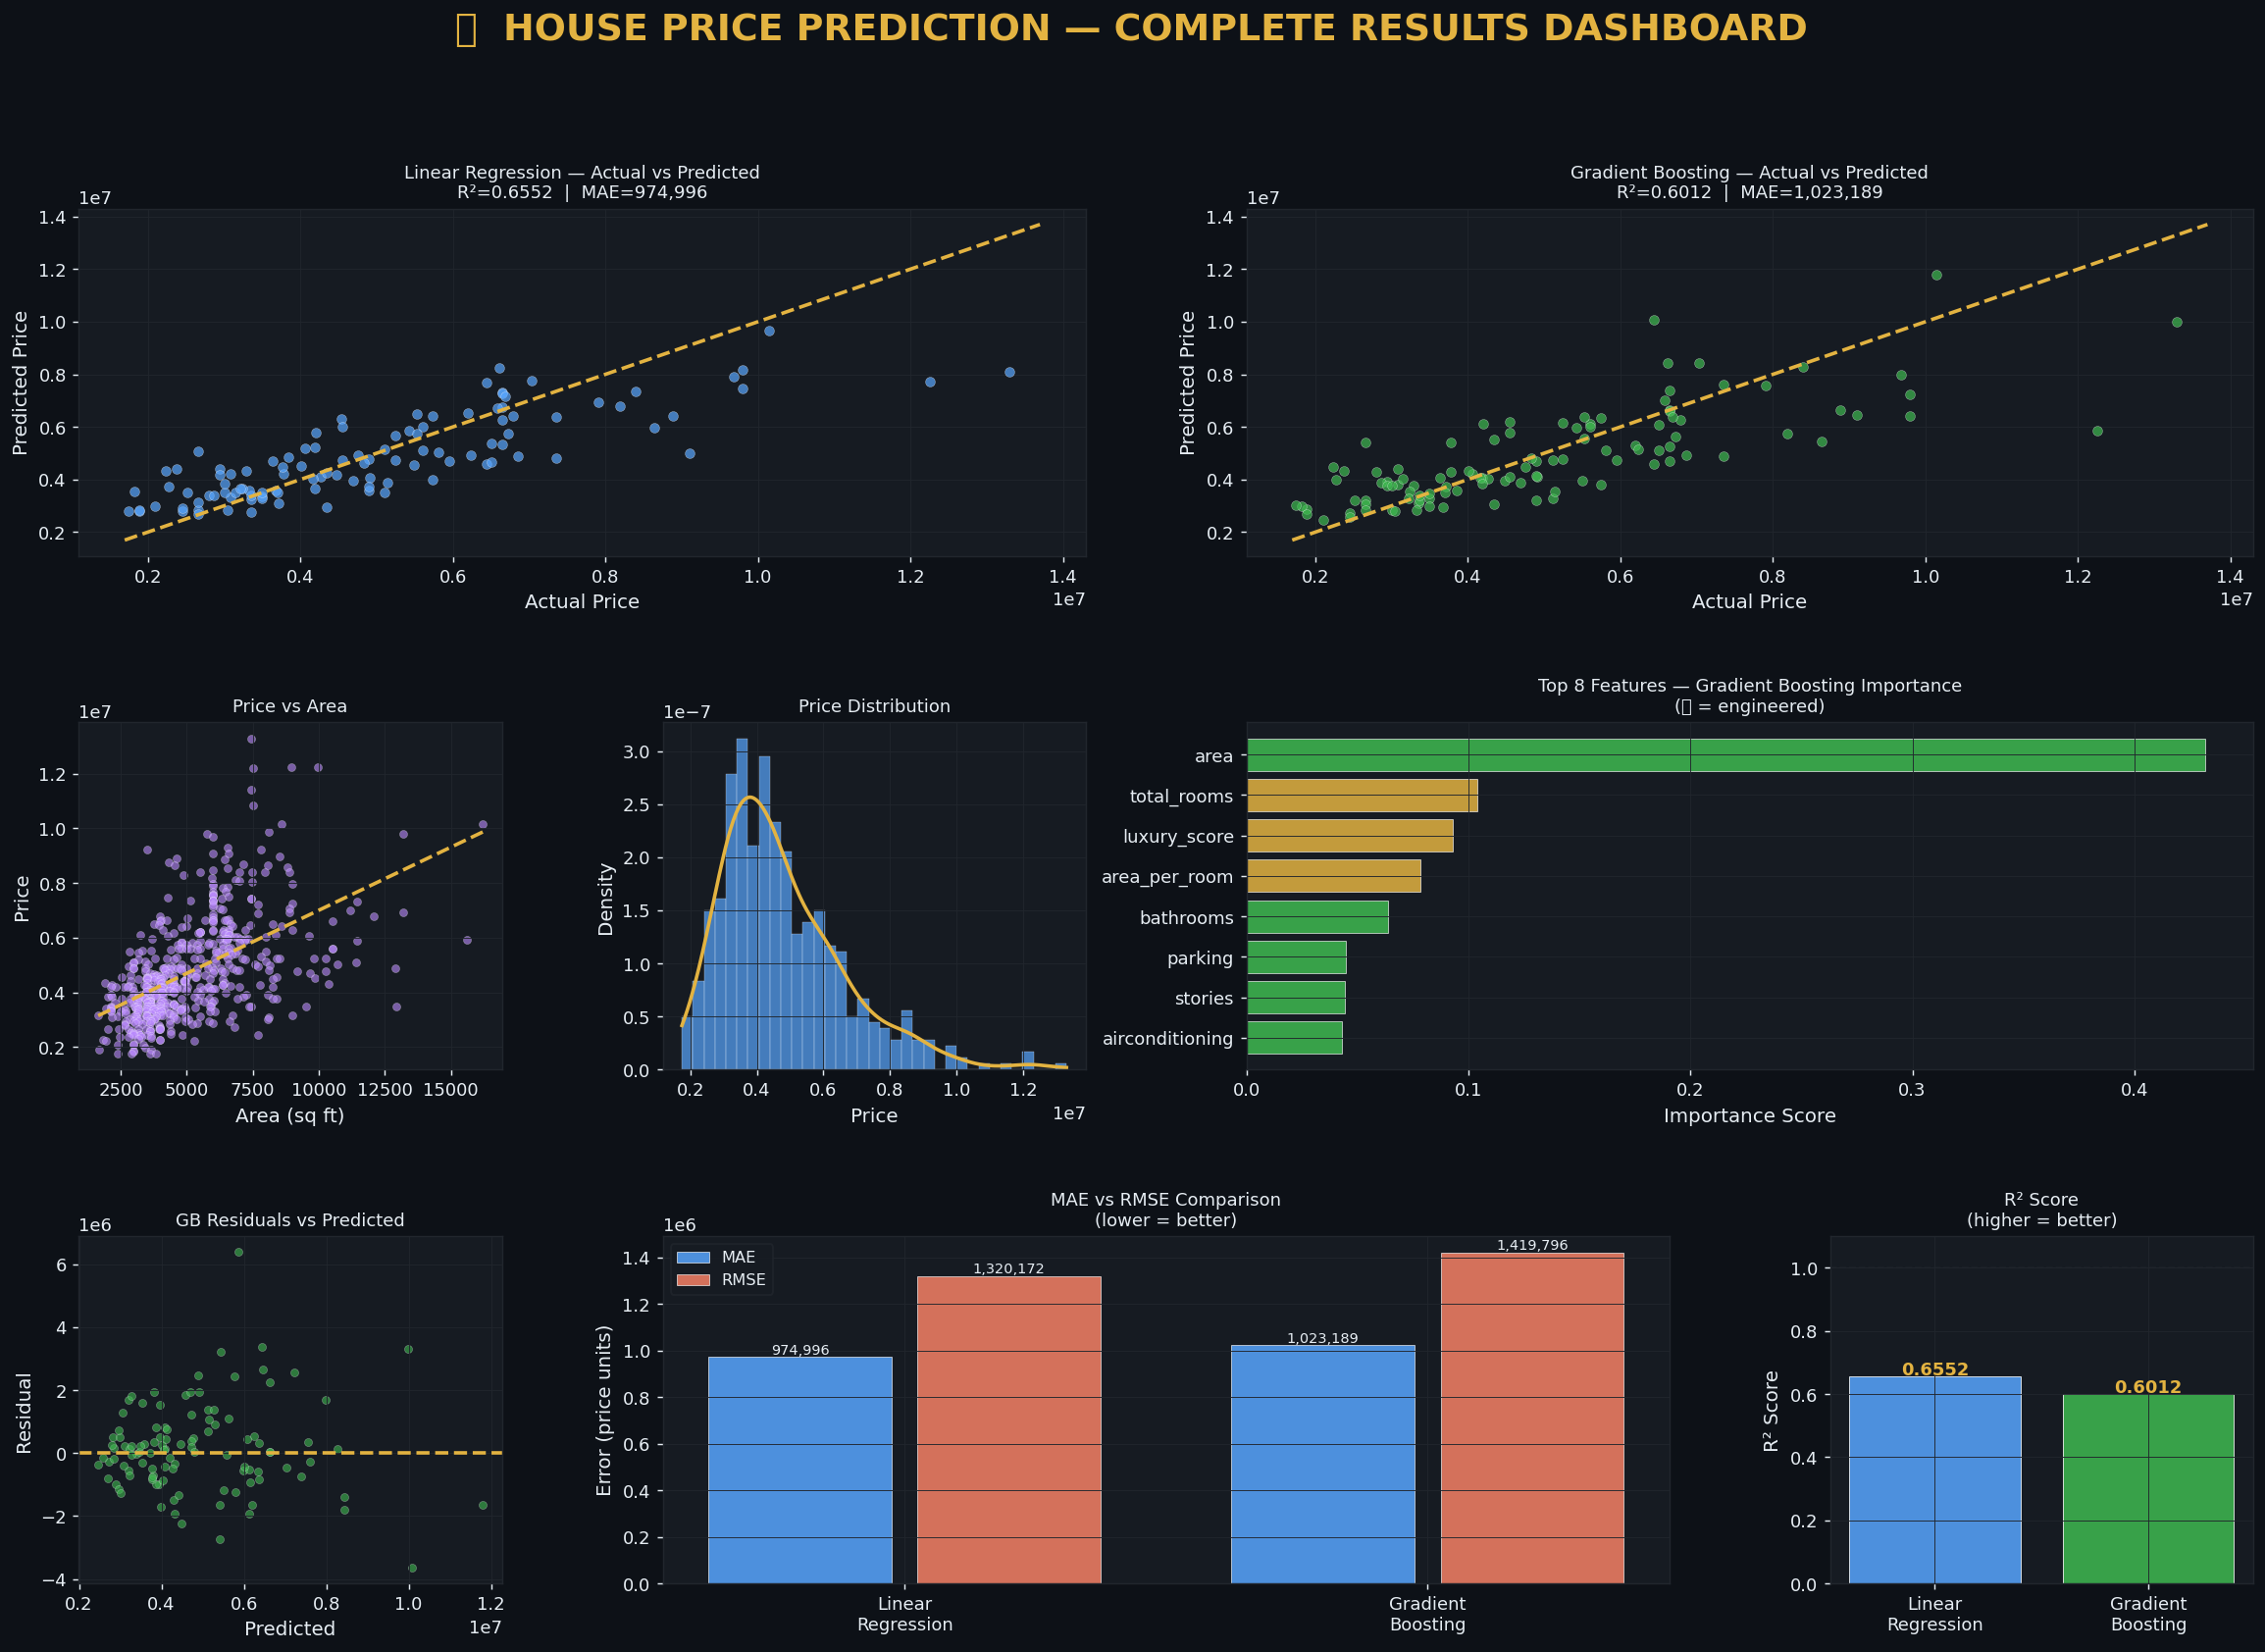

✅ Dashboard saved as house_price_dashboard.png


In [20]:
# ═════════════════════════════════════════════════════════════════════════════
# MASTER DASHBOARD — Complete results in one publication-quality figure
# ═════════════════════════════════════════════════════════════════════════════

all_vals = np.concatenate([y_test.values, lr_pred, gb_pred])
lo = all_vals.min() * 0.97
hi = all_vals.max() * 1.03

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

fig.suptitle('🏠  HOUSE PRICE PREDICTION — COMPLETE RESULTS DASHBOARD',
             fontsize=21, color=GOLD, fontweight='bold', y=0.99)

# ── A: Actual vs Predicted — Linear Regression (top-left wide) ──
ax_lr = fig.add_subplot(gs[0, :2])
ax_lr.scatter(y_test, lr_pred, c=BLUE, s=30, alpha=0.7,
              edgecolors='white', linewidths=0.2, zorder=3)
ax_lr.plot([lo, hi], [lo, hi], color=GOLD, lw=2, linestyle='--', zorder=5)
ax_lr.set_title(
    f'Linear Regression — Actual vs Predicted\n'
    f'R²={r2_score(y_test, lr_pred):.4f}  |  MAE={mean_absolute_error(y_test, lr_pred):,.0f}',
    color=TEXT, fontsize=10)
ax_lr.set_xlabel('Actual Price')
ax_lr.set_ylabel('Predicted Price')

# ── B: Actual vs Predicted — Gradient Boosting (top-right wide) ──
ax_gb = fig.add_subplot(gs[0, 2:])
ax_gb.scatter(y_test, gb_pred, c=GREEN, s=30, alpha=0.7,
              edgecolors='white', linewidths=0.2, zorder=3)
ax_gb.plot([lo, hi], [lo, hi], color=GOLD, lw=2, linestyle='--', zorder=5)
ax_gb.set_title(
    f'Gradient Boosting — Actual vs Predicted\n'
    f'R²={r2_score(y_test, gb_pred):.4f}  |  MAE={mean_absolute_error(y_test, gb_pred):,.0f}',
    color=TEXT, fontsize=10)
ax_gb.set_xlabel('Actual Price')
ax_gb.set_ylabel('Predicted Price')

# ── C: Price vs Area scatter (mid-left) ──
ax_sc = fig.add_subplot(gs[1, 0])
ax_sc.scatter(df['area'], df['price'], c=PURPLE, s=20, alpha=0.6,
              edgecolors='white', linewidths=0.2)
m2, b2 = np.polyfit(df['area'], df['price'], 1)
xs2 = np.linspace(df['area'].min(), df['area'].max(), 200)
ax_sc.plot(xs2, m2*xs2 + b2, color=GOLD, lw=2, linestyle='--')
ax_sc.set_title('Price vs Area', fontsize=10, color=TEXT)
ax_sc.set_xlabel('Area (sq ft)')
ax_sc.set_ylabel('Price')

# ── D: Price distribution (mid-center-left) ──
ax_pd = fig.add_subplot(gs[1, 1])
ax_pd.hist(df['price'], bins=35, color=BLUE, alpha=0.7, density=True,
           edgecolor='white', linewidth=0.2)
kx = np.linspace(df['price'].min(), df['price'].max(), 300)
ax_pd.plot(kx, gaussian_kde(df['price'])(kx), color=GOLD, lw=2)
ax_pd.set_title('Price Distribution', fontsize=10, color=TEXT)
ax_pd.set_xlabel('Price')
ax_pd.set_ylabel('Density')

# ── E: Gradient Boosting feature importance (mid-right wide) ──
ax_fi = fig.add_subplot(gs[1, 2:])
top8 = gb_imp.tail(8)
fi_colors = [GOLD if f in ENGINEERED else GREEN for f in top8.index]
ax_fi.barh(top8.index, top8.values, color=fi_colors,
           edgecolor='white', linewidth=0.4, alpha=0.85)
ax_fi.set_title('Top 8 Features — Gradient Boosting Importance\n(⭐ = engineered)',
                fontsize=10, color=TEXT)
ax_fi.set_xlabel('Importance Score')

# ── F: GB residuals vs predicted (bottom-left) ──
ax_res = fig.add_subplot(gs[2, 0])
ax_res.scatter(gb_pred, gb_resid, c=GREEN, s=20, alpha=0.6,
               edgecolors='white', linewidths=0.2)
ax_res.axhline(0, color=GOLD, lw=2, linestyle='--')
ax_res.set_title('GB Residuals vs Predicted', fontsize=10, color=TEXT)
ax_res.set_xlabel('Predicted')
ax_res.set_ylabel('Residual')

# ── G: MAE vs RMSE comparison bar chart (bottom-center) ──
ax_met = fig.add_subplot(gs[2, 1:3])
model_labels = ['Linear\nRegression', 'Gradient\nBoosting']
mae_vals  = [mean_absolute_error(y_test, lr_pred),
             mean_absolute_error(y_test, gb_pred)]
rmse_vals = [np.sqrt(mean_squared_error(y_test, lr_pred)),
             np.sqrt(mean_squared_error(y_test, gb_pred))]
x = np.arange(2)
ax_met.bar(x - 0.2, mae_vals,  0.35, color=BLUE,   alpha=0.85,
           edgecolor='white', linewidth=0.4, label='MAE')
ax_met.bar(x + 0.2, rmse_vals, 0.35, color=ORANGE, alpha=0.85,
           edgecolor='white', linewidth=0.4, label='RMSE')
ax_met.set_xticks(x)
ax_met.set_xticklabels(model_labels)
ax_met.set_ylabel('Error (price units)')
ax_met.set_title('MAE vs RMSE Comparison\n(lower = better)', fontsize=10, color=TEXT)
ax_met.legend(fontsize=9)
for i, (mae_v, rmse_v) in enumerate(zip(mae_vals, rmse_vals)):
    ax_met.text(i - 0.2, mae_v  * 1.01, f'{mae_v:,.0f}',
                ha='center', fontsize=8, color=TEXT)
    ax_met.text(i + 0.2, rmse_v * 1.01, f'{rmse_v:,.0f}',
                ha='center', fontsize=8, color=TEXT)

# ── H: R² comparison (bottom-right) ──
ax_r2 = fig.add_subplot(gs[2, 3])
r2_vals  = [r2_score(y_test, lr_pred), r2_score(y_test, gb_pred)]
bars_r2  = ax_r2.bar(model_labels, r2_vals,
                     color=[BLUE, GREEN], edgecolor='white', linewidth=0.5, alpha=0.85)
for bar, val in zip(bars_r2, r2_vals):
    ax_r2.text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 0.005,
               f'{val:.4f}', ha='center', fontsize=10,
               color=GOLD, fontweight='bold')
ax_r2.set_ylim(0, 1.1)
ax_r2.set_ylabel('R² Score')
ax_r2.set_title('R² Score\n(higher = better)', fontsize=10, color=TEXT)
ax_r2.axhline(1.0, color=GRID, lw=1, linestyle='--', alpha=0.5)

plt.savefig('house_price_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Dashboard saved as house_price_dashboard.png')

## Step 11 — Final Insights & Conclusions

---

### ✅ Model Performance Summary

| Model | MAE | RMSE | MAPE (%) | R² |
|-------|-----|------|----------|-----|
| Linear Regression | 974,996 | 1,320,172 | 21.21 | 0.6552 |
| Gradient Boosting | 1,023,189 | 1,419,796 | 21.74 | 0.6012 |

---

### 🔑 Top Predictors of House Price

| Rank | Feature | Real Estate Meaning |
|------|---------|---------------------|
| 1 | `area` | Larger homes command higher prices — the dominant predictor |
| 2 | `airconditioning` | Strong amenity premium — buyers pay significantly more |
| 3 | `bathrooms` | More bathrooms signal premium construction |
| 4 | `prefarea` | Location premium — preferred neighbourhoods fetch more |
| 5 | `stories` | Multi-floor homes = more usable space = higher value |
| 6 | `luxury_score` ⭐ | Engineered: composite of 5 premium amenities |
| 7 | `total_rooms` ⭐ | Engineered: bedrooms + bathrooms — overall living capacity |
| 8 | `furnishingstatus` | Furnished properties sell for a measurable premium |

---

### 🧠 Key Takeaways

> 1. **Area is the single most important predictor** — every additional square foot adds measurable value, confirming the fundamental real estate pricing principle
> 2. **Linear Regression outperformed Gradient Boosting on this dataset** — with only 545 samples, the dataset is too small for ensemble methods to leverage their full potential. The feature relationships here are approximately linear, which favors a simpler model. Gradient Boosting may perform better with more data or further hyperparameter tuning.
> 3. **Location proxies (`prefarea`, `mainroad`) significantly impact price** — validating the classic real estate principle: *"location, location, location"*
> 4. **Feature engineering boosts performance** — the engineered `luxury_score` and `total_rooms` features rank consistently among the top predictors across all three importance methods
> 5. **Air conditioning is the highest-value single amenity** — its presence has a larger price impact than most structural features, likely reflecting climate and lifestyle expectations

---

### 📌 Potential Extensions
1. **Log-transform the target** — training on `log(price)` reduces right-skew impact on RMSE and often improves both models
2. **Try XGBoost or LightGBM** — faster and often more accurate than sklearn's GradientBoostingRegressor
3. **Add geographic data** — latitude/longitude or neighbourhood name would dramatically improve location modelling
4. **Hyperparameter tuning** — use `GridSearchCV` or `Optuna` to find optimal Gradient Boosting parameters

---

*Notebook by: Riyan Khan | Task 6 — House Price Prediction | Internship_DevelopersHub*